# Comprehensive Results Visualization for All 4 Models

This section loads and visualizes results from all 4 models:
- VulBERTa
- LineVul  
- StagedVulBERT
- PD-BERT

In [ ]:
# Load results from all 4 models for type1-4 transformations
import pickle
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define model paths
model_paths = {
    'VulBERTa': './data/VulBERTa/results_1024',
    'PDBERT': './data/PDBERT/downstream/results_512',
    'LineVul': './data/LineVul/results_512',
    'StagedVulBERT': './data/StagedVulBERT/results_2048',
    
}

perturbations_type = ['type1', 'type2', 'type3', 'type4']

def load_metrics_from_pkl(model_name, perturbation, split='train'):
    """Load predictions and labels from pkl files and compute metrics"""
    base_path = model_paths[model_name]
    
    try:
        # Load clean data
        clean_pred = pickle.load(open(f'{base_path}/clean_{split}_pred.pkl', 'rb'))
        clean_labels = pickle.load(open(f'{base_path}/clean_{split}_labels.pkl', 'rb'))
        
        # Load perturbed data
        perturbed_pred = pickle.load(open(f'{base_path}/{perturbation}_{split}_perturbed_pred.pkl', 'rb'))
        perturbed_labels = pickle.load(open(f'{base_path}/{perturbation}_{split}_perturbed_labels.pkl', 'rb'))
        
        # Compute metrics for clean
        clean_metrics = {
            'accuracy': accuracy_score(clean_labels, clean_pred),
            'precision': precision_score(clean_labels, clean_pred, average='binary', zero_division=0),
            'recall': recall_score(clean_labels, clean_pred, average='binary', zero_division=0),
            'f1': f1_score(clean_labels, clean_pred, average='binary', zero_division=0)
        }
            
        
        # Compute metrics for perturbed
        perturbed_metrics = {
            'accuracy': accuracy_score(perturbed_labels, perturbed_pred),
            'precision': precision_score(perturbed_labels, perturbed_pred, average='binary', zero_division=0),
            'recall': recall_score(perturbed_labels, perturbed_pred, average='binary', zero_division=0),
            'f1': f1_score(perturbed_labels, perturbed_pred, average='binary', zero_division=0)
        }
        
        # Calculate percentage change
        change = {}
        for metric in ['accuracy', 'precision', 'recall', 'f1']:
            clean_val = clean_metrics[metric] * 100
            perturbed_val = perturbed_metrics[metric] * 100
            change[metric] = perturbed_val - clean_val
        
        return change
    except FileNotFoundError as e:
        print(f"Warning: Could not find files for {model_name} - {perturbation} - {split}")
        return None
    except Exception as e:
        print(f"Error loading {model_name} - {perturbation} - {split}: {e}")
        return None

# Collect all metrics
all_results_train = {}
all_results_test = {}

for model_name in model_paths.keys():
    all_results_train[model_name] = {}
    all_results_test[model_name] = {}
    
    for pert in perturbations_type:
        train_change = load_metrics_from_pkl(model_name, pert, 'train')
        test_change = load_metrics_from_pkl(model_name, pert, 'test')
        
        if train_change:
            all_results_train[model_name][pert] = train_change
        if test_change:
            all_results_test[model_name][pert] = test_change

print("✓ Loaded all results for type1-4 transformations")
print(f"Models: {list(model_paths.keys())}")
print(f"Perturbations: {perturbations_type}")
print(f"Metrics: {list(all_results_train['VulBERTa']['type1'].keys())}")

# Check which models have data
print("\nData availability:")
for model_name in model_paths.keys():
    train_count = len(all_results_train.get(model_name, {}))
    test_count = len(all_results_test.get(model_name, {}))
    print(f"  {model_name}: {train_count} train perturbations, {test_count} test perturbations")

✓ Loaded all results for type1-4 transformations
Models: ['VulBERTa', 'PDBERT', 'LineVul', 'StagedVulBERT']
Perturbations: ['type1', 'type2', 'type3', 'type4']
Metrics: ['accuracy', 'precision', 'recall', 'f1']

Data availability:
  VulBERTa: 4 train perturbations, 4 test perturbations
  PDBERT: 4 train perturbations, 4 test perturbations
  LineVul: 4 train perturbations, 4 test perturbations
  StagedVulBERT: 4 train perturbations, 4 test perturbations


In [7]:
model_names = ['VulBERTa', 'PDBERT', 'LineVul', 'StagedVulBERT' ]
def load_metrics_from_pkl_filtered(model_name, perturbation, split='train'):
    """Load predictions and labels from pkl files and compute metrics"""
    base_path = model_paths[model_name]
    
    try:
        # Load clean data
        clean_pred = pickle.load(open(f'{base_path}/clean_{split}_pred.pkl', 'rb'))
        clean_labels = pickle.load(open(f'{base_path}/clean_{split}_labels.pkl', 'rb'))
        
        # Load perturbed data
        perturbed_pred = pickle.load(open(f'{base_path}/{perturbation}_{split}_perturbed_pred.pkl', 'rb'))
        perturbed_labels = pickle.load(open(f'{base_path}/{perturbation}_{split}_perturbed_labels.pkl', 'rb'))
        
        if model_name == 'PDBERT' or 'VulBERTa' in model_name:
            with open(f"./data/perturbed_devign_1024/type4/{split}_indices.txt") as f:
                indices_type4 = [int(line.strip()) for line in f.readlines()]
            with open(f"./data/perturbed_devign/clean/{split}_indices.txt") as f:
                indices_clean = [int(line.strip()) for line in f.readlines()]
            clean_pred = {idx : pred for idx, pred in zip(indices_clean, clean_pred)}
            clean_labels = {idx : label for idx, label in zip(indices_clean, clean_labels)}

            perturbed_pred = {idx : pred for idx, pred in zip(indices_clean, perturbed_pred)}
            perturbed_labels = {idx : label for idx, label in zip(indices_clean, perturbed_labels)}
            clean_pred_filtered = [clean_pred[i] for i in indices_type4]
            clean_labels_filtered = [clean_labels[i] for i in indices_type4]

            perturbed_pred_filtered = [perturbed_pred[i] for i in indices_type4]
            perturbed_labels_filtered = [perturbed_labels[i] for i in indices_type4]

        else:
            with open(f"./data/perturbed_big_vul_2048/type4/{split}_indices.txt") as f:
                indices_type4 = [int(line.strip()) for line in f.readlines()]
            clean_pred_filtered = [clean_pred[i] for i in indices_type4]
            clean_labels_filtered = [clean_labels[i] for i in indices_type4]

            perturbed_pred_filtered = [perturbed_pred[i] for i in indices_type4]
            perturbed_labels_filtered = [perturbed_labels[i] for i in indices_type4]

        clean_pred = clean_pred_filtered
        clean_labels = clean_labels_filtered

        perturbed_pred = perturbed_pred_filtered
        perturbed_labels = perturbed_labels_filtered

        # Compute metrics for clean
        clean_metrics = {
            'accuracy': accuracy_score(clean_labels, clean_pred),
            'precision': precision_score(clean_labels, clean_pred, average='binary', zero_division=0),
            'recall': recall_score(clean_labels, clean_pred, average='binary', zero_division=0),
            'f1': f1_score(clean_labels, clean_pred, average='binary', zero_division=0)
        }
            
        
        # Compute metrics for perturbed
        perturbed_metrics = {
            'accuracy': accuracy_score(perturbed_labels, perturbed_pred),
            'precision': precision_score(perturbed_labels, perturbed_pred, average='binary', zero_division=0),
            'recall': recall_score(perturbed_labels, perturbed_pred, average='binary', zero_division=0),
            'f1': f1_score(perturbed_labels, perturbed_pred, average='binary', zero_division=0)
        }
        
        # Calculate percentage change
        change = {}
        for metric in ['accuracy', 'precision', 'recall', 'f1']:
            clean_val = clean_metrics[metric] * 100
            perturbed_val = perturbed_metrics[metric] * 100
            change[metric] = perturbed_val - clean_val
        
        return change
    except FileNotFoundError as e:
        print(f"Warning: Could not find files for {model_name} - {perturbation} - {split}")
        return None
    except Exception as e:
        print(f"Error loading {model_name} - {perturbation} - {split}: {e}")
        raise e
        return None

# Collect all metrics
all_results_train_filtered = {}
all_results_test_filtered = {}

for model_name in model_paths.keys():
    all_results_train_filtered[model_name] = {}
    all_results_test_filtered[model_name] = {}
    
    for pert in perturbations_type:
        if pert != 'type4':
            train_change = load_metrics_from_pkl_filtered(model_name, pert, 'train')
            test_change = load_metrics_from_pkl_filtered(model_name, pert, 'test')
        else:
            train_change = load_metrics_from_pkl(model_name, pert, 'train')
            test_change = load_metrics_from_pkl(model_name, pert, 'test')
        
        if train_change:
            all_results_train_filtered[model_name][pert] = train_change
        if test_change:
            all_results_test_filtered[model_name][pert] = test_change

print("✓ Loaded all results for type1-4 transformations")
print(f"Models: {list(model_paths.keys())}")
print(f"Perturbations: {perturbations_type}")
print(f"Metrics: {list(all_results_train_filtered['VulBERTa']['type1'].keys())}")

# Check which models have data
print("\nData availability:")
for model_name in model_paths.keys():
    train_count = len(all_results_train_filtered.get(model_name, {}))
    test_count = len(all_results_test_filtered.get(model_name, {}))
    print(f"  {model_name}: {train_count} train perturbations, {test_count} test perturbations")
        

✓ Loaded all results for type1-4 transformations
Models: ['VulBERTa', 'PDBERT', 'LineVul', 'StagedVulBERT']
Perturbations: ['type1', 'type2', 'type3', 'type4']
Metrics: ['accuracy', 'precision', 'recall', 'f1']

Data availability:
  VulBERTa: 4 train perturbations, 4 test perturbations
  PDBERT: 4 train perturbations, 4 test perturbations
  LineVul: 4 train perturbations, 4 test perturbations
  StagedVulBERT: 4 train perturbations, 4 test perturbations


# Train All


TRAIN SET - Data check before plotting:
  VulBERTa: 4 perturbations = ['type1', 'type2', 'type3', 'type4']
  PDBERT: 4 perturbations = ['type1', 'type2', 'type3', 'type4']
  LineVul: 4 perturbations = ['type1', 'type2', 'type3', 'type4']
  StagedVulBERT: 4 perturbations = ['type1', 'type2', 'type3', 'type4']


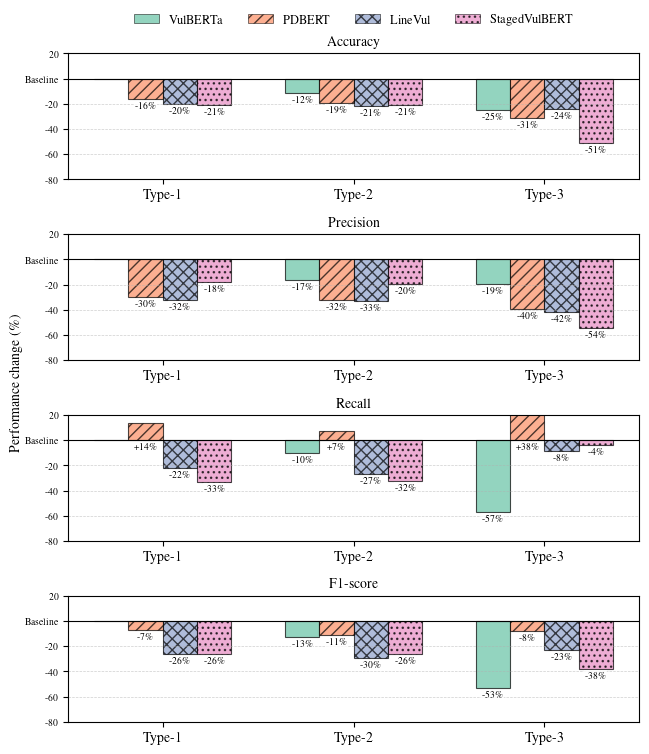

In [9]:
# Plot Type 1-4 Transformations - TRAIN SET
import matplotlib.pyplot as plt
import matplotlib as mpl

# IEEE figure style
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "axes.unicode_minus": False,
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 7,
    "legend.fontsize": 9,
})

# Colorblind-safe palette
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']  # 4 colors for 4 models
hatches = ['', '///', 'xxx', '...']

model_names = ['VulBERTa', 'PDBERT', 'LineVul', 'StagedVulBERT' ]
types = ["Type-1", "Type-2", "Type-3"]
x = np.arange(len(types))
bar_width = 0.18

def autolabel_bars(ax, bars, ymin=-100, ymax=20):
    """Attach +X% / -X% labels to bars"""
    for bar in bars:
        height = bar.get_height()
        if height == 0 or abs(height) < 1:
            continue
        
        # Position label based on bar direction
        if height > 0:
            # Positive values: place label just below x-axis
            y_pos = -2
            va = "top"
        else:
            # Negative values: place label just below the bar
            y_pos = height - 2
            va = "top"
        
        label = f"{height:+.0f}\\%"
        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, y_pos),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center",
            va=va,
            fontsize=7,
            color='black',
            fontweight='bold',
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.8)
        )

# Prepare data for plotting
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
metric_keys = ['accuracy', 'precision', 'recall', 'f1']

# Debug: Print what data we have for each model
print("\nTRAIN SET - Data check before plotting:")
for model_name in model_names:
    if model_name in all_results_train:
        perts = list(all_results_train[model_name].keys())
        print(f"  {model_name}: {len(perts)} perturbations = {perts}")
    else:
        print(f"  {model_name}: NO DATA IN all_results_train")

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(7, 8), sharex=True, sharey=True)
ymin, ymax = -65, 20

for i, (metric_name, metric_key) in enumerate(zip(metric_names, metric_keys)):
    ax = axes[i]
    ax.axhline(0, color="black", linewidth=0.8)
    
    # Collect data for each model
    all_bars = []
    for j, model_name in enumerate(model_names):
        data = []
        for pert in perturbations_type[:3]:
            if pert in all_results_train[model_name]:
                data.append(all_results_train[model_name][pert][metric_key])
            else:
                data.append(0)
        
        # Plot bars with offset
        offset = (j - 1.5) * bar_width
        bars = ax.bar(x + offset, data, width=bar_width, 
                      color=colors[j], hatch=hatches[j],
                      edgecolor='black', linewidth=0.8, alpha=0.7,
                      label=model_name if i == 0 else None)
        all_bars.append(bars)
        autolabel_bars(ax, bars, ymin, ymax)
    
    ax.set_ylim(ymin, ymax)
    # Replace 0 tick label with "Baseline"
    yticks = ax.get_yticks()
    ytick_labels = []

    for t in yticks:
        if abs(t) < 1e-6:   # identify zero safely
            ytick_labels.append("Baseline")
        else:
            ytick_labels.append(f"{int(t)}")

    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)
    ax.set_title(metric_name, pad=6)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    
    # Legend only on first subplot
    if i == 0:
        legend_handles = [
            plt.Rectangle((0,0), 1, 1, facecolor=colors[j], 
                          edgecolor='black', linewidth=0.5, 
                          hatch=hatches[j], alpha=0.7,
                          label=model_names[j])
            for j in range(len(model_names))
        ]
        ax.legend(
            handles=legend_handles,
            ncol=4,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.4),
            frameon=False
        )

# Bottom axis ticks
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(types)
    ax.tick_params(axis='x', labelbottom=True)
# Shared y-label
fig.text(0.08, 0.5, "Performance change (\\%)", va="center", rotation="vertical")
#fig.suptitle("Type 1-4 Transformations - TRAIN SET", fontsize=12, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0.08, 0.03, 1, 0.99])
plt.savefig("type_1_3_train_all_models.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Filtered Train


TRAIN SET - Data check before plotting:
  VulBERTa: 4 perturbations = ['type1', 'type2', 'type3', 'type4']
  PDBERT: 4 perturbations = ['type1', 'type2', 'type3', 'type4']
  LineVul: 4 perturbations = ['type1', 'type2', 'type3', 'type4']
  StagedVulBERT: 4 perturbations = ['type1', 'type2', 'type3', 'type4']


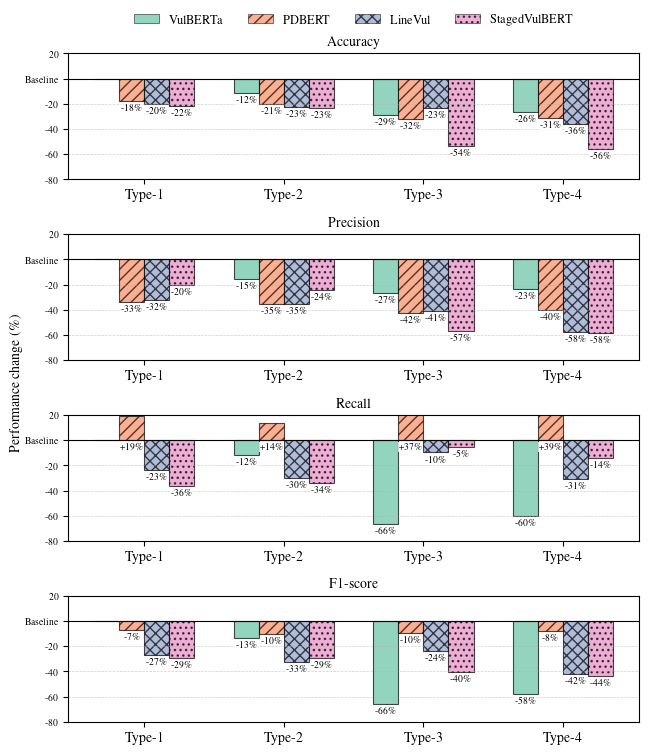

In [4]:
# Plot Type 1-4 Transformations - TRAIN SET
import matplotlib.pyplot as plt
import matplotlib as mpl

# IEEE figure style
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "axes.unicode_minus": False,
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 7,
    "legend.fontsize": 9,
})

# Colorblind-safe palette
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']  # 4 colors for 4 models
hatches = ['', '///', 'xxx', '...']

model_names = ['VulBERTa', 'PDBERT', 'LineVul', 'StagedVulBERT' ]
types = ["Type-1", "Type-2", "Type-3", "Type-4"]
x = np.arange(len(types))
bar_width = 0.18

def autolabel_bars(ax, bars, ymin=-100, ymax=20):
    """Attach +X% / -X% labels to bars"""
    for bar in bars:
        height = bar.get_height()
        if height == 0 or abs(height) < 1:
            continue
        
        # Position label based on bar direction
        if height > 0:
            # Positive values: place label just below x-axis
            y_pos = -2
            va = "top"
        else:
            # Negative values: place label just below the bar
            y_pos = height - 2
            va = "top"
        
        label = f"{height:+.0f}\\%"
        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, y_pos),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center",
            va=va,
            fontsize=7,
            color='black',
            fontweight='bold',
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.8)
        )

# Prepare data for plotting
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
metric_keys = ['accuracy', 'precision', 'recall', 'f1']

# Debug: Print what data we have for each model
print("\nTRAIN SET - Data check before plotting:")
for model_name in model_names:
    if model_name in all_results_train_filtered:
        perts = list(all_results_train_filtered[model_name].keys())
        print(f"  {model_name}: {len(perts)} perturbations = {perts}")
    else:
        print(f"  {model_name}: NO DATA IN all_results_train_filtered")
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(7, 8), sharex=True, sharey=True)
ymin, ymax = -65, 20

for i, (metric_name, metric_key) in enumerate(zip(metric_names, metric_keys)):
    ax = axes[i]
    ax.axhline(0, color="black", linewidth=0.8)
    
    # Collect data for each model
    all_bars = []
    for j, model_name in enumerate(model_names):
        data = []
        for pert in perturbations_type:
            if pert in all_results_train_filtered[model_name]:
                data.append(all_results_train_filtered[model_name][pert][metric_key])
            else:
                data.append(0)
        
        # Plot bars with offset
        offset = (j - 1.5) * bar_width
        bars = ax.bar(x + offset, data, width=bar_width, 
                      color=colors[j], hatch=hatches[j],
                      edgecolor='black', linewidth=0.8, alpha=0.7,
                      label=model_name if i == 0 else None)
        all_bars.append(bars)
        autolabel_bars(ax, bars, ymin, ymax)
    
    ax.set_ylim(ymin, ymax)
    # Replace 0 tick label with "Baseline"
    yticks = ax.get_yticks()
    ytick_labels = []

    for t in yticks:
        if abs(t) < 1e-6:   # identify zero safely
            ytick_labels.append("Baseline")
        else:
            ytick_labels.append(f"{int(t)}")

    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)
    ax.set_title(metric_name, pad=6)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    
    # Legend only on first subplot
    if i == 0:
        legend_handles = [
            plt.Rectangle((0,0), 1, 1, facecolor=colors[j], 
                          edgecolor='black', linewidth=0.5, 
                          hatch=hatches[j], alpha=0.7,
                          label=model_names[j])
            for j in range(len(model_names))
        ]
        ax.legend(
            handles=legend_handles,
            ncol=4,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.4),
            frameon=False
        )

# Bottom axis ticks
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(types)
    ax.tick_params(axis='x', labelbottom=True)
# Shared y-label
fig.text(0.08, 0.5, "Performance change (\\%)", va="center", rotation="vertical")
#fig.suptitle("Type 1-4 Transformations - TRAIN SET", fontsize=12, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0.08, 0.03, 1, 0.99])
plt.savefig("type_1_4_train_filtered_all_models.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Test All 


TEST SET - Data check before plotting:
  VulBERTa: 4 perturbations = ['type1', 'type2', 'type3', 'type4']
  PDBERT: 4 perturbations = ['type1', 'type2', 'type3', 'type4']
  LineVul: 4 perturbations = ['type1', 'type2', 'type3', 'type4']
  StagedVulBERT: 4 perturbations = ['type1', 'type2', 'type3', 'type4']


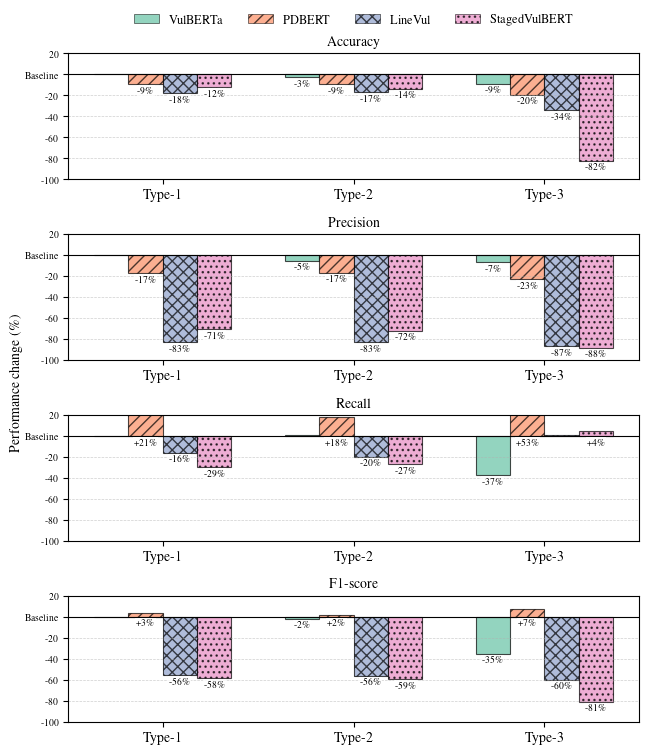

In [5]:
# Plot Type 1-4 Transformations - TRAIN SET
import matplotlib.pyplot as plt
import matplotlib as mpl

# IEEE figure style
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "axes.unicode_minus": False,
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 7,
    "legend.fontsize": 9,
})

# Colorblind-safe palette
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']  # 4 colors for 4 models
hatches = ['', '///', 'xxx', '...']

model_names = ['VulBERTa', 'PDBERT', 'LineVul', 'StagedVulBERT' ]
types = ["Type-1", "Type-2", "Type-3"]
x = np.arange(len(types))
bar_width = 0.18

def autolabel_bars(ax, bars, ymin=-100, ymax=20):
    """Attach +X% / -X% labels to bars"""
    for bar in bars:
        height = bar.get_height()
        if height == 0 or abs(height) < 1:
            continue
        
        # Position label based on bar direction
        if height > 0:
            # Positive values: place label just below x-axis
            y_pos = -2
            va = "top"
        else:
            # Negative values: place label just below the bar
            y_pos = height - 2
            va = "top"
        
        label = f"{height:+.0f}\\%"
        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, y_pos),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center",
            va=va,
            fontsize=7,
            color='black',
            fontweight='bold',
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.8)
        )

# Prepare data for plotting
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
metric_keys = ['accuracy', 'precision', 'recall', 'f1']

# Debug: Print what data we have for each model
print("\nTEST SET - Data check before plotting:")
for model_name in model_names:
    if model_name in all_results_test:
        perts = list(all_results_test[model_name].keys())
        print(f"  {model_name}: {len(perts)} perturbations = {perts}")
    else:
        print(f"  {model_name}: NO DATA IN all_results_test")
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(7, 8), sharex=True, sharey=True)
ymin, ymax = -100, 20

for i, (metric_name, metric_key) in enumerate(zip(metric_names, metric_keys)):
    ax = axes[i]
    ax.axhline(0, color="black", linewidth=0.8)
    
    # Collect data for each model
    all_bars = []
    for j, model_name in enumerate(model_names):
        data = []
        for pert in perturbations_type[:3]:
            if pert in all_results_test[model_name]:
                data.append(all_results_test[model_name][pert][metric_key])
            else:
                data.append(0)
        
        # Plot bars with offset
        offset = (j - 1.5) * bar_width
        bars = ax.bar(x + offset, data, width=bar_width, 
                      color=colors[j], hatch=hatches[j],
                      edgecolor='black', linewidth=0.8, alpha=0.7,
                      label=model_name if i == 0 else None)
        all_bars.append(bars)
        autolabel_bars(ax, bars, ymin, ymax)
    
    ax.set_ylim(ymin, ymax)
    # Replace 0 tick label with "Baseline"
    yticks = ax.get_yticks()
    ytick_labels = []

    for t in yticks:
        if abs(t) < 1e-6:   # identify zero safely
            ytick_labels.append("Baseline")
        else:
            ytick_labels.append(f"{int(t)}")

    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)
    ax.set_title(metric_name, pad=6)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    
    # Legend only on first subplot
    if i == 0:
        legend_handles = [
            plt.Rectangle((0,0), 1, 1, facecolor=colors[j], 
                          edgecolor='black', linewidth=0.5, 
                          hatch=hatches[j], alpha=0.7,
                          label=model_names[j])
            for j in range(len(model_names))
        ]
        ax.legend(
            handles=legend_handles,
            ncol=4,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.4),
            frameon=False
        )

# Bottom axis ticks
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(types)
    ax.tick_params(axis='x', labelbottom=True)
# Shared y-label
fig.text(0.08, 0.5, "Performance change (\\%)", va="center", rotation="vertical")
#fig.suptitle("Type 1-4 Transformations - TRAIN SET", fontsize=12, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0.08, 0.03, 1, 0.99])
plt.savefig("type_1_3_test_all_models.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Filtered Test


TRAIN SET - Data check before plotting:
  VulBERTa: 4 perturbations = ['type1', 'type2', 'type3', 'type4']
  PDBERT: 4 perturbations = ['type1', 'type2', 'type3', 'type4']
  LineVul: 4 perturbations = ['type1', 'type2', 'type3', 'type4']
  StagedVulBERT: 4 perturbations = ['type1', 'type2', 'type3', 'type4']


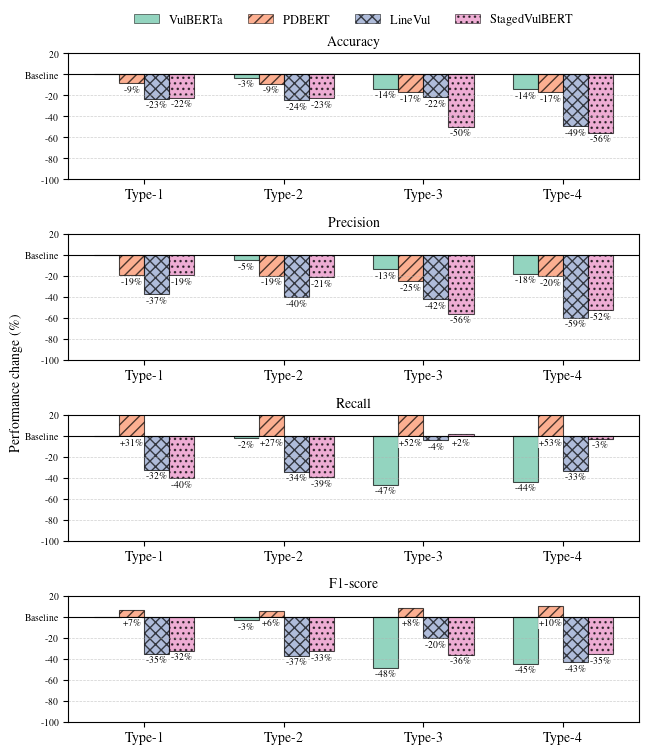

In [6]:
# Plot Type 1-4 Transformations - TRAIN SET
import matplotlib.pyplot as plt
import matplotlib as mpl

# IEEE figure style
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "axes.unicode_minus": False,
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 7,
    "legend.fontsize": 9,
})

# Colorblind-safe palette
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']  # 4 colors for 4 models
hatches = ['', '///', 'xxx', '...']

model_names = ['VulBERTa', 'PDBERT', 'LineVul', 'StagedVulBERT' ]
types = ["Type-1", "Type-2", "Type-3", "Type-4"]
x = np.arange(len(types))
bar_width = 0.18

def autolabel_bars(ax, bars, ymin=-100, ymax=20):
    """Attach +X% / -X% labels to bars"""
    for bar in bars:
        height = bar.get_height()
        if height == 0 or abs(height) < 1:
            continue
        
        # Position label based on bar direction
        if height > 0:
            # Positive values: place label just below x-axis
            y_pos = -2
            va = "top"
        else:
            # Negative values: place label just below the bar
            y_pos = height - 2
            va = "top"
        
        label = f"{height:+.0f}\\%"
        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, y_pos),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center",
            va=va,
            fontsize=7,
            color='black',
            fontweight='bold',
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.8)
        )

# Prepare data for plotting
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
metric_keys = ['accuracy', 'precision', 'recall', 'f1']

# Debug: Print what data we have for each model
print("\nTRAIN SET - Data check before plotting:")
for model_name in model_names:
    if model_name in all_results_test_filtered:
        perts = list(all_results_test_filtered[model_name].keys())
        print(f"  {model_name}: {len(perts)} perturbations = {perts}")
    else:
        print(f"  {model_name}: NO DATA IN all_results_test_filtered")
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(7, 8), sharex=True, sharey=True)
ymin, ymax = -100, 20

for i, (metric_name, metric_key) in enumerate(zip(metric_names, metric_keys)):
    ax = axes[i]
    ax.axhline(0, color="black", linewidth=0.8)
    
    # Collect data for each model
    all_bars = []
    for j, model_name in enumerate(model_names):
        data = []
        for pert in perturbations_type:
            if pert in all_results_test_filtered[model_name]:
                data.append(all_results_test_filtered[model_name][pert][metric_key])
            else:
                data.append(0)
        
        # Plot bars with offset
        offset = (j - 1.5) * bar_width
        bars = ax.bar(x + offset, data, width=bar_width, 
                      color=colors[j], hatch=hatches[j],
                      edgecolor='black', linewidth=0.8, alpha=0.7,
                      label=model_name if i == 0 else None)
        all_bars.append(bars)
        autolabel_bars(ax, bars, ymin, ymax)
    
    ax.set_ylim(ymin, ymax)
    # Replace 0 tick label with "Baseline"
    yticks = ax.get_yticks()
    ytick_labels = []

    for t in yticks:
        if abs(t) < 1e-6:   # identify zero safely
            ytick_labels.append("Baseline")
        else:
            ytick_labels.append(f"{int(t)}")

    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)
    ax.set_title(metric_name, pad=6)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    
    # Legend only on first subplot
    if i == 0:
        legend_handles = [
            plt.Rectangle((0,0), 1, 1, facecolor=colors[j], 
                          edgecolor='black', linewidth=0.5, 
                          hatch=hatches[j], alpha=0.7,
                          label=model_names[j])
            for j in range(len(model_names))
        ]
        ax.legend(
            handles=legend_handles,
            ncol=4,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.4),
            frameon=False
        )

# Bottom axis ticks
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(types)
    ax.tick_params(axis='x', labelbottom=True)
# Shared y-label
fig.text(0.08, 0.5, "Performance change (\\%)", va="center", rotation="vertical")
#fig.suptitle("Type 1-4 Transformations - TRAIN SET", fontsize=12, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0.08, 0.03, 1, 0.99])
plt.savefig("type_1_4_test_filtered_all_models.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Load results for tf_N transformations (TEST only)
perturbations_tf = ['T1_1', 'T1_2', 'T2_1', 'T2_2', 'T3_1', 'T3_2', 'T3_3', 'T3_4']

all_results_tf_test = {}

for model_name in model_paths.keys():
    all_results_tf_test[model_name] = {}
    
    for pert in perturbations_tf:
        test_change = load_metrics_from_pkl(model_name, pert, 'test')
        
        if test_change:
            all_results_tf_test[model_name][pert] = test_change

print("✓ Loaded all results for tf_1 to tf_13 transformations (TEST only)")
print(f"Models: {list(model_paths.keys())}")
print(f"Perturbations: {perturbations_tf}")

✓ Loaded all results for tf_1 to tf_13 transformations (TEST only)
Models: ['VulBERTa', 'PDBERT', 'LineVul', 'StagedVulBERT']
Perturbations: ['T1_1', 'T1_2', 'T2_1', 'T2_2', 'T3_1', 'T3_2', 'T3_3', 'T3_4']


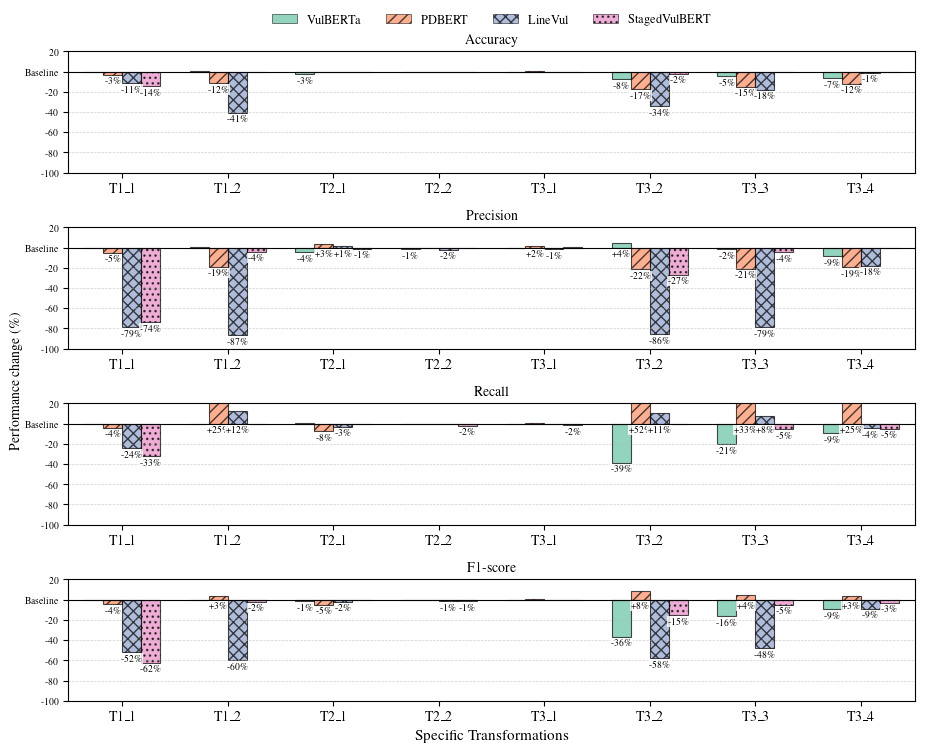

In [11]:
# Plot Transformations Ordered by Type - TEST SET
# Filter out transformations with None mapping and sort by TX.Y
# filtered_tf = [(tf_key, mapping[tf_key]) for tf_key in perturbations_tf if mapping.get(tf_key) is not None]
# Sort by TX.Y value (e.g., T1.1, T1.2, T1.3, T2.1, T2.2, T3.1, T3.2, T3.3)
# filtered_tf.sort(key=lambda x: x[1])

# Extract ordered tf_keys and labels
ordered_tf_keys = perturbations_tf
ordered_labels = perturbations_tf

x_tf = np.arange(len(ordered_tf_keys))
bar_width_tf = 0.18

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 8), sharex=True, sharey=True)
ymin, ymax = -100, 20

for i, (metric_name, metric_key) in enumerate(zip(metric_names, metric_keys)):
    ax = axes[i]
    ax.axhline(0, color="black", linewidth=0.8)
    
    # Collect data for each model
    all_bars = []
    for j, model_name in enumerate(model_names):
        data = []
        for pert in ordered_tf_keys:
            if pert in all_results_tf_test[model_name]:
                data.append(all_results_tf_test[model_name][pert][metric_key])
            else:
                data.append(0)
        
        # Plot bars with offset
        offset = (j - 1.5) * bar_width_tf
        bars = ax.bar(x_tf + offset, data, width=bar_width_tf, 
                      color=colors[j], hatch=hatches[j],
                      edgecolor='black', linewidth=0.8, alpha=0.7,
                      label=model_name if i == 0 else None)
        all_bars.append(bars)
        autolabel_bars(ax, bars, ymin, ymax)
    
    ax.set_ylim(ymin, ymax)
    ax.set_title(metric_name, pad=6)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    
    # Legend only on first subplot
    # Legend only on first subplot
    if i == 0:
        legend_handles = [
            plt.Rectangle((0,0), 1, 1, facecolor=colors[j], 
                          edgecolor='black', linewidth=0.5, 
                          hatch=hatches[j], alpha=0.7,
                          label=model_names[j])
            for j in range(len(model_names))
        ]
        ax.legend(
            handles=legend_handles,
            ncol=4,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.4),
            frameon=False
        )
yticks = ax.get_yticks()
ytick_labels = []

for t in yticks:
    if abs(t) < 1e-6:   # identify zero safely
        ytick_labels.append("Baseline")
    else:
        ytick_labels.append(f"{int(t)}")

ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labels)     

# Bottom axis ticks with TX.Y labels
for ax in axes:
    ax.set_xticks(x_tf)
    ax.set_xticklabels(ordered_labels)
    ax.tick_params(axis='x', labelbottom=True)
    ax.margins(x=0.02)

# X-axis label with specific transformation mapping
xlabel_text = "Specific Transformations"
axes[-1].set_xlabel(xlabel_text, fontsize=11)

# Shared y-label
fig.text(0.08, 0.5, "Performance change (\\%)", va="center", rotation="vertical")

plt.tight_layout(rect=[0.08, 0.03, 1, 0.99])
plt.savefig("transformations_ordered_test_all_models.pdf", dpi=300, bbox_inches='tight')
plt.show()


## PCA Analysis for All Models

Visualizing feature space shifts for type1-4 transformations across all 4 models

In [12]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ── shared KDE/scatter helper ────────────────────────────────────────────────
def _plot_density_or_hex(ax, df, group_col, groups_colors):
    """KDE (filled + contour) when ≥20 pts, scatter fallback otherwise."""
    for name, color in groups_colors:
        subset = df[df[group_col] == name]
        if len(subset) == 0:
            continue
        if len(subset) >= 20:
            try:
                sns.kdeplot(data=subset, x='PC1', y='PC2',
                            fill=True, levels=8, alpha=0.3, color=color, ax=ax)
                sns.kdeplot(data=subset, x='PC1', y='PC2',
                            fill=False, levels=8, color=color, linewidths=1, ax=ax)
            except Exception:
                ax.scatter(subset['PC1'], subset['PC2'],
                           c=color, s=12, alpha=0.4, linewidths=0)
        elif len(subset) >= 5:
            ax.scatter(subset['PC1'], subset['PC2'],
                       c=color, s=25, alpha=0.7, edgecolors='k', linewidths=0.2, zorder=4)
        else:
            ax.scatter(subset['PC1'], subset['PC2'],
                       c=color, s=40, alpha=0.9, edgecolors='k', linewidths=0.4, zorder=5)


# ── balanced sampling helper ─────────────────────────────────────────────────
def _balanced_sample(pca2, labels, preds, max_points):
    n = len(pca2)
    if max_points is None or n <= max_points:
        return pca2, labels, preds
    np.random.seed(42)
    vul_idx  = np.where(labels == 1)[0]
    safe_idx = np.where(labels == 0)[0]
    n_per = min(len(vul_idx), len(safe_idx), max_points // 2)
    if n_per == 0:
        idx = np.random.choice(n, size=max_points, replace=False)
    else:
        sv = np.random.choice(vul_idx,  size=n_per, replace=False)
        ss = np.random.choice(safe_idx, size=n_per, replace=False)
        idx = np.concatenate([sv, ss])
        rem = np.setdiff1d(np.arange(n), idx)
        n_ex = max_points - len(idx)
        if n_ex > 0 and len(rem) > 0:
            idx = np.concatenate([idx, np.random.choice(rem, size=min(n_ex, len(rem)), replace=False)])
        np.random.shuffle(idx)
    return pca2[idx], labels[idx], preds[idx]


# ── main plotting function ───────────────────────────────────────────────────
def plot_pca_model_all_perturbations(
        model_name,
        perturbations,          # e.g. ['type1', 'type2', 'type3', 'type4']
        split='train',
        max_points=2000,
        vuln_min_warn=50,
        figsize=(28, 10),
        save_path=None,
):
    """
    Creates a 2 × (1 + len(perturbations)) figure for one model:
      Row 1  — Safe / Vulnerable KDE:      Clean | Type1 | Type2 | Type3 | Type4
      Row 2  — Correct / Incorrect KDE:    Clean | Type1 | Type2 | Type3 | Type4
    """
    ncols = 1 + len(perturbations)
    fig, axes = plt.subplots(2, ncols, figsize=figsize, squeeze=False)

    base_path = model_paths[model_name]

    LABEL_GROUPS   = [('Safe', '#377eb8'), ('Vulnerable', '#e41a1c')]
    CORRECT_GROUPS = [(True,  '#66c2a5'), (False, '#fc8d62')]
    LEG_LABEL   = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#377eb8', markersize=8, label='Safe'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='#e41a1c', markersize=8, label='Vulnerable')]
    LEG_CORRECT = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#66c2a5', markersize=8, label='Correct'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='#fc8d62', markersize=8, label='Incorrect')]

    # ── Column 0: Clean (loaded from first available perturbation's pkl) ────
    ref_data = None
    for pert in perturbations:
        try:
            ref_data = pickle.load(open(f"{base_path}/{pert}_{split}_pca_comparison.pkl", 'rb'))
            break
        except FileNotFoundError:
            continue

    if ref_data is None:
        print(f"[{model_name}] No pkl files found — nothing to plot.")
        plt.close(fig)
        return

    c_pca_all    = np.asarray(ref_data['clean_features_pca'])[:, :2]
    c_labels_all = np.asarray(ref_data['clean_labels'])
    c_preds_all  = np.asarray(ref_data['clean_predictions'])
    evr_ref = ref_data.get('explained_variance_ratio', [0, 0])
    ev1_c, ev2_c = f"{evr_ref[0]:.2%}", f"{evr_ref[1]:.2%}"

    print(f"{model_name} - clean ({split}): {len(c_pca_all)} samples "
          f"(vul={int(np.sum(c_labels_all==1))}, safe={int(np.sum(c_labels_all==0))})")
    if int(np.sum(c_labels_all == 1)) < vuln_min_warn:
        print(f"  Warning: only {int(np.sum(c_labels_all==1))} vulnerable examples — KDE may be unstable.")

    c_pca, c_labels, c_preds = _balanced_sample(c_pca_all, c_labels_all, c_preds_all, max_points)

    df_clean = pd.DataFrame({
        'PC1':    c_pca[:, 0],
        'PC2':    c_pca[:, 1],
        'Label':  ['Vulnerable' if l == 1 else 'Safe' for l in c_labels],
        'Correct': [l == p for l, p in zip(c_labels, c_preds)],
    })

    _plot_density_or_hex(axes[0][0], df_clean, 'Label',   LABEL_GROUPS)
    axes[0][0].set_title(f'Clean ({split})', fontsize=9, fontweight='bold')
    axes[0][0].set_xlabel(f'PC1 ({ev1_c})', fontsize=8)
    axes[0][0].set_ylabel(f'PC2 ({ev2_c})', fontsize=8)
    axes[0][0].legend(handles=LEG_LABEL,   loc='best', frameon=True, fontsize=7)
    axes[0][0].grid(alpha=0.3)

    _plot_density_or_hex(axes[1][0], df_clean, 'Correct', CORRECT_GROUPS)
    axes[1][0].set_title(f'Clean Correctness', fontsize=9, fontweight='bold')
    axes[1][0].set_xlabel(f'PC1 ({ev1_c})', fontsize=8)
    axes[1][0].set_ylabel(f'PC2 ({ev2_c})', fontsize=8)
    axes[1][0].legend(handles=LEG_CORRECT, loc='best', frameon=True, fontsize=7)
    axes[1][0].grid(alpha=0.3)

    # ── Columns 1…n: one per perturbation ───────────────────────────────────
    for col, pert in enumerate(perturbations, start=1):
        pkl_file = f"{base_path}/{pert}_{split}_pca_comparison.pkl"
        try:
            data = pickle.load(open(pkl_file, 'rb'))
        except FileNotFoundError:
            print(f"  [{model_name}] {pkl_file} not found — skipping column.")
            axes[0][col].set_visible(False)
            axes[1][col].set_visible(False)
            continue

        p_pca_all    = np.asarray(data['perturbed_features_pca'])[:, :2]
        p_labels_all = np.asarray(data['perturbed_labels'])
        p_preds_all  = np.asarray(data['perturbed_predictions'])
        evr = data.get('explained_variance_ratio', [0, 0])
        ev1_p, ev2_p = f"{evr[0]:.2%}", f"{evr[1]:.2%}"

        print(f"{model_name} - {pert} ({split}): {len(p_pca_all)} samples "
              f"(vul={int(np.sum(p_labels_all==1))}, safe={int(np.sum(p_labels_all==0))})")

        p_pca, p_labels, p_preds = _balanced_sample(p_pca_all, p_labels_all, p_preds_all, max_points)

        df_pert = pd.DataFrame({
            'PC1':    p_pca[:, 0],
            'PC2':    p_pca[:, 1],
            'Label':  ['Vulnerable' if l == 1 else 'Safe' for l in p_labels],
            'Correct': [l == p for l, p in zip(p_labels, p_preds)],
        })

        _plot_density_or_hex(axes[0][col], df_pert, 'Label',   LABEL_GROUPS)
        axes[0][col].set_title(f'{pert.upper()} ({split})', fontsize=9, fontweight='bold')
        axes[0][col].set_xlabel(f'PC1 ({ev1_p})', fontsize=8)
        axes[0][col].set_ylabel(f'PC2 ({ev2_p})', fontsize=8)
        axes[0][col].legend(handles=LEG_LABEL,   loc='best', frameon=True, fontsize=7)
        axes[0][col].grid(alpha=0.3)

        _plot_density_or_hex(axes[1][col], df_pert, 'Correct', CORRECT_GROUPS)
        axes[1][col].set_title(f'{pert.upper()} Correctness', fontsize=9, fontweight='bold')
        axes[1][col].set_xlabel(f'PC1 ({ev1_p})', fontsize=8)
        axes[1][col].set_ylabel(f'PC2 ({ev2_p})', fontsize=8)
        axes[1][col].legend(handles=LEG_CORRECT, loc='best', frameon=True, fontsize=7)
        axes[1][col].grid(alpha=0.3)

    plt.suptitle(f'{model_name} — PCA Analysis ({split})', fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()


print("✓ plot_pca_model_all_perturbations defined")


✓ plot_pca_model_all_perturbations defined


In [11]:
# PCA Analysis - Single Perturbation Across All Models (fixed)
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_pca_for_model(model_name, perturbation, split='train', ax_row=None, max_points=2000):
    """Plot PCA for a specific model and perturbation.

    Fixes:
      - Balanced sampling without accidental overwrite.
      - Clear PCA axis labels with closing parenthesis and percent.
      - Vulnerable & incorrect points plotted on top for visibility.
      - Reliable legend for Correct/Incorrect using custom handles.
      - Warn when vulnerable examples are small (<50).
    """
    base_path = model_paths[model_name]
    pkl_file = f"{base_path}/{perturbation}_{split}_pca_comparison.pkl"

    try:
        data = pickle.load(open(pkl_file, 'rb'))
    except FileNotFoundError:
        print(f"Warning: Could not find PCA file for {model_name} - {perturbation} - {split}")
        return None

    # Extract PCA components (first 2 dimensions)
    clean_pca = data['clean_features_pca'][:, :2]
    perturbed_pca = data['perturbed_features_pca'][:, :2]

    # labels/preds arrays
    all_clean_labels = np.array(data['clean_labels'])
    all_clean_preds  = np.array(data['clean_predictions'])
    all_pert_labels  = np.array(data['perturbed_labels'])
    all_pert_preds   = np.array(data['perturbed_predictions'])

    n_samples = len(clean_pca)
    print(f"{model_name} - {perturbation} - {split}: Total samples = {n_samples}")

    # Sampling with class balance and no accidental overwrite
    if max_points is not None and n_samples > max_points:
        np.random.seed(42)
        vul_idx  = np.where(all_clean_labels == 1)[0]
        safe_idx = np.where(all_clean_labels == 0)[0]
        n_vul = len(vul_idx); n_safe = len(safe_idx)
        print(f"  Vulnerable samples: {n_vul}, Safe samples: {n_safe}")

        if n_vul < 50:
            print(f"  Warning: Vulnerable examples for {model_name} are low ({n_vul} < 50) — plots may underrepresent this class.")

        # target roughly half-half if possible
        n_per_class = max_points // 2
        take_vul  = min(n_vul, n_per_class)
        take_safe = min(n_safe, n_per_class)

        sampled_vul  = np.random.choice(vul_idx,  size=take_vul,  replace=False) if take_vul > 0 else np.array([], dtype=int)
        sampled_safe = np.random.choice(safe_idx, size=take_safe, replace=False) if take_safe > 0 else np.array([], dtype=int)

        sample_idx = np.concatenate([sampled_vul, sampled_safe])
        remaining = max_points - len(sample_idx)
        if remaining > 0:
            # fill remaining from the pool of indices not yet selected
            remaining_pool = np.setdiff1d(np.arange(n_samples), sample_idx)
            if len(remaining_pool) >= remaining:
                more = np.random.choice(remaining_pool, size=remaining, replace=False)
            else:
                more = remaining_pool  # take what is left
            sample_idx = np.concatenate([sample_idx, more])

        np.random.shuffle(sample_idx)

        clean_pca = clean_pca[sample_idx]
        perturbed_pca = perturbed_pca[sample_idx]
        clean_labels = all_clean_labels[sample_idx].tolist()
        clean_predictions = all_clean_preds[sample_idx].tolist()
        perturbed_labels = all_pert_labels[sample_idx].tolist()
        perturbed_predictions = all_pert_preds[sample_idx].tolist()
        print(f"  Sampling {len(sample_idx)} points (vul={take_vul}, safe={take_safe}, filled={remaining})")
    else:
        clean_labels = all_clean_labels.tolist()
        clean_predictions = all_clean_preds.tolist()
        perturbed_labels = all_pert_labels.tolist()
        perturbed_predictions = all_pert_preds.tolist()

    # helper to get explained variance safely and format explicitly
    evr = data.get("explained_variance_ratio", None)
    if evr is None or len(evr) < 2:
        ev1_str = "n/a"
        ev2_str = "n/a"
    else:
        ev1_str = f"{evr[0]*100:.2f}%"
        ev2_str = f"{evr[1]*100:.2f}%"

    # Create DataFrames
    df_clean = pd.DataFrame({
        'PC1': clean_pca[:, 0],
        'PC2': clean_pca[:, 1],
        'Label': ['Vulnerable' if label == 1 else 'Safe' for label in clean_labels],
        'Prediction': ['Vulnerable' if pred == 1 else 'Safe' for pred in clean_predictions],
        'Correct': [label == pred for label, pred in zip(clean_labels, clean_predictions)],
    })

    df_perturbed = pd.DataFrame({
        'PC1': perturbed_pca[:, 0],
        'PC2': perturbed_pca[:, 1],
        'Label': ['Vulnerable' if label == 1 else 'Safe' for label in perturbed_labels],
        'Prediction': ['Vulnerable' if pred == 1 else 'Safe' for pred in perturbed_predictions],
        'Correct': [label == pred for label, pred in zip(perturbed_labels, perturbed_predictions)],
    })

    if ax_row is not None:
        # colors
        label_palette = {'Vulnerable': '#e41a1c', 'Safe': '#377eb8'}
        correct_palette = {True: '#66c2a5', False: '#fc8d62'}

        # --- Subplot 1: Clean data - colored by label (plot safe first, vulnerable on top) ---
        ax1 = ax_row[0]
        # Safe first
        for lbl in ['Safe', 'Vulnerable']:
            subset = df_clean[df_clean['Label'] == lbl]
            if subset.shape[0] == 0:
                continue
            ax1.scatter(subset['PC1'], subset['PC2'],
                        c=label_palette[lbl],
                        s=15, alpha=0.8, linewidths=0, label=lbl,
                        zorder=2 if lbl == 'Safe' else 3)
        ax1.set_title(f'{model_name} - Clean ({split})', fontsize=10, fontweight='bold')
        ax1.set_xlabel(f'PC1 ({ev1_str})', fontsize=8)
        ax1.set_ylabel(f'PC2 ({ev2_str})', fontsize=8)
        # create legend from custom patches to ensure colors show
        ax1.legend(handles=[Patch(color=label_palette['Vulnerable'], label='Vulnerable'),
                            Patch(color=label_palette['Safe'], label='Safe')],
                   loc='best', frameon=True, fontsize=7)
        ax1.grid(alpha=0.3)

        # --- Subplot 2: Perturbed data - colored by label (safe first) ---
        ax2 = ax_row[1]
        for lbl in ['Safe', 'Vulnerable']:
            subset = df_perturbed[df_perturbed['Label'] == lbl]
            if subset.shape[0] == 0:
                continue
            ax2.scatter(subset['PC1'], subset['PC2'],
                        c=label_palette[lbl],
                        s=15, alpha=0.8, linewidths=0, label=lbl,
                        zorder=2 if lbl == 'Safe' else 3)
        ax2.set_title(f'{model_name} - {perturbation.upper()} ({split})', fontsize=10, fontweight='bold')
        ax2.set_xlabel(f'PC1 ({ev1_str})', fontsize=8)
        ax2.set_ylabel(f'PC2 ({ev2_str})', fontsize=8)
        ax2.legend(handles=[Patch(color=label_palette['Vulnerable'], label='Vulnerable'),
                            Patch(color=label_palette['Safe'], label='Safe')],
                   loc='best', frameon=True, fontsize=7)
        ax2.grid(alpha=0.3)

        # --- Subplot 3: Clean data - colored by correctness (plot correct first, incorrect on top) ---
        ax3 = ax_row[2]
        # Correct first (lower zorder), incorrect on top for visibility
        for correctness in [True, False]:
            subset = df_clean[df_clean['Correct'] == correctness]
            if subset.shape[0] == 0:
                continue
            ax3.scatter(subset['PC1'], subset['PC2'],
                        c=correct_palette[correctness],
                        s=18, alpha=0.85, linewidths=0,
                        zorder=2 if correctness is True else 4,
                        label='Correct' if correctness else 'Incorrect')
        ax3.set_title(f'{model_name} - Clean Correctness', fontsize=10, fontweight='bold')
        ax3.set_xlabel(f'PC1 ({ev1_str})', fontsize=8)
        ax3.set_ylabel(f'PC2 ({ev2_str})', fontsize=8)
        # custom legend to ensure colors are shown and in desired order
        ax3.legend(handles=[Patch(color=correct_palette[True], label='Correct'),
                            Patch(color=correct_palette[False], label='Incorrect')],
                   loc='best', frameon=True, fontsize=7)
        ax3.grid(alpha=0.3)

        # --- Subplot 4: Perturbed data - colored by correctness (incorrect on top) ---
        ax4 = ax_row[3]
        for correctness in [True, False]:
            subset = df_perturbed[df_perturbed['Correct'] == correctness]
            if subset.shape[0] == 0:
                continue
            ax4.scatter(subset['PC1'], subset['PC2'],
                        c=correct_palette[correctness],
                        s=18, alpha=0.85, linewidths=0,
                        zorder=2 if correctness is True else 4,
                        label='Correct' if correctness else 'Incorrect')
        ax4.set_title(f'{model_name} - {perturbation.upper()} Correctness', fontsize=10, fontweight='bold')
        ax4.set_xlabel(f'PC1 ({ev1_str})', fontsize=8)
        ax4.set_ylabel(f'PC2 ({ev2_str})', fontsize=8)
        ax4.legend(handles=[Patch(color=correct_palette[True], label='Correct'),
                            Patch(color=correct_palette[False], label='Incorrect')],
                   loc='best', frameon=True, fontsize=7)
        ax4.grid(alpha=0.3)

    return data

print("✓ PCA plotting function (fixed) defined")

✓ PCA plotting function (fixed) defined


[VulBERTa] Surrogate SVM fitted on 21854 train samples.
  [VulBERTa] type1_test_features.pkl not found, using pca_comparison coords.
  [VulBERTa] type2_test_features.pkl not found, using pca_comparison coords.
  [VulBERTa] type3_test_features.pkl not found, using pca_comparison coords.
  [VulBERTa] type4_test_features.pkl not found, using pca_comparison coords.
[PDBERT] Surrogate SVM fitted on 21854 train samples.
  [PDBERT] type1_test_features.pkl not found, using pca_comparison coords.
  [PDBERT] type2_test_features.pkl not found, using pca_comparison coords.
  [PDBERT] type3_test_features.pkl not found, using pca_comparison coords.
  [PDBERT] type4_test_features.pkl not found, using pca_comparison coords.
[LineVul] Surrogate SVM fitted on 20000 train samples.
  [LineVul] type1_test_features.pkl not found, using pca_comparison coords.
  [LineVul] type2_test_features.pkl not found, using pca_comparison coords.
  [LineVul] type3_test_features.pkl not found, using pca_comparison coords.

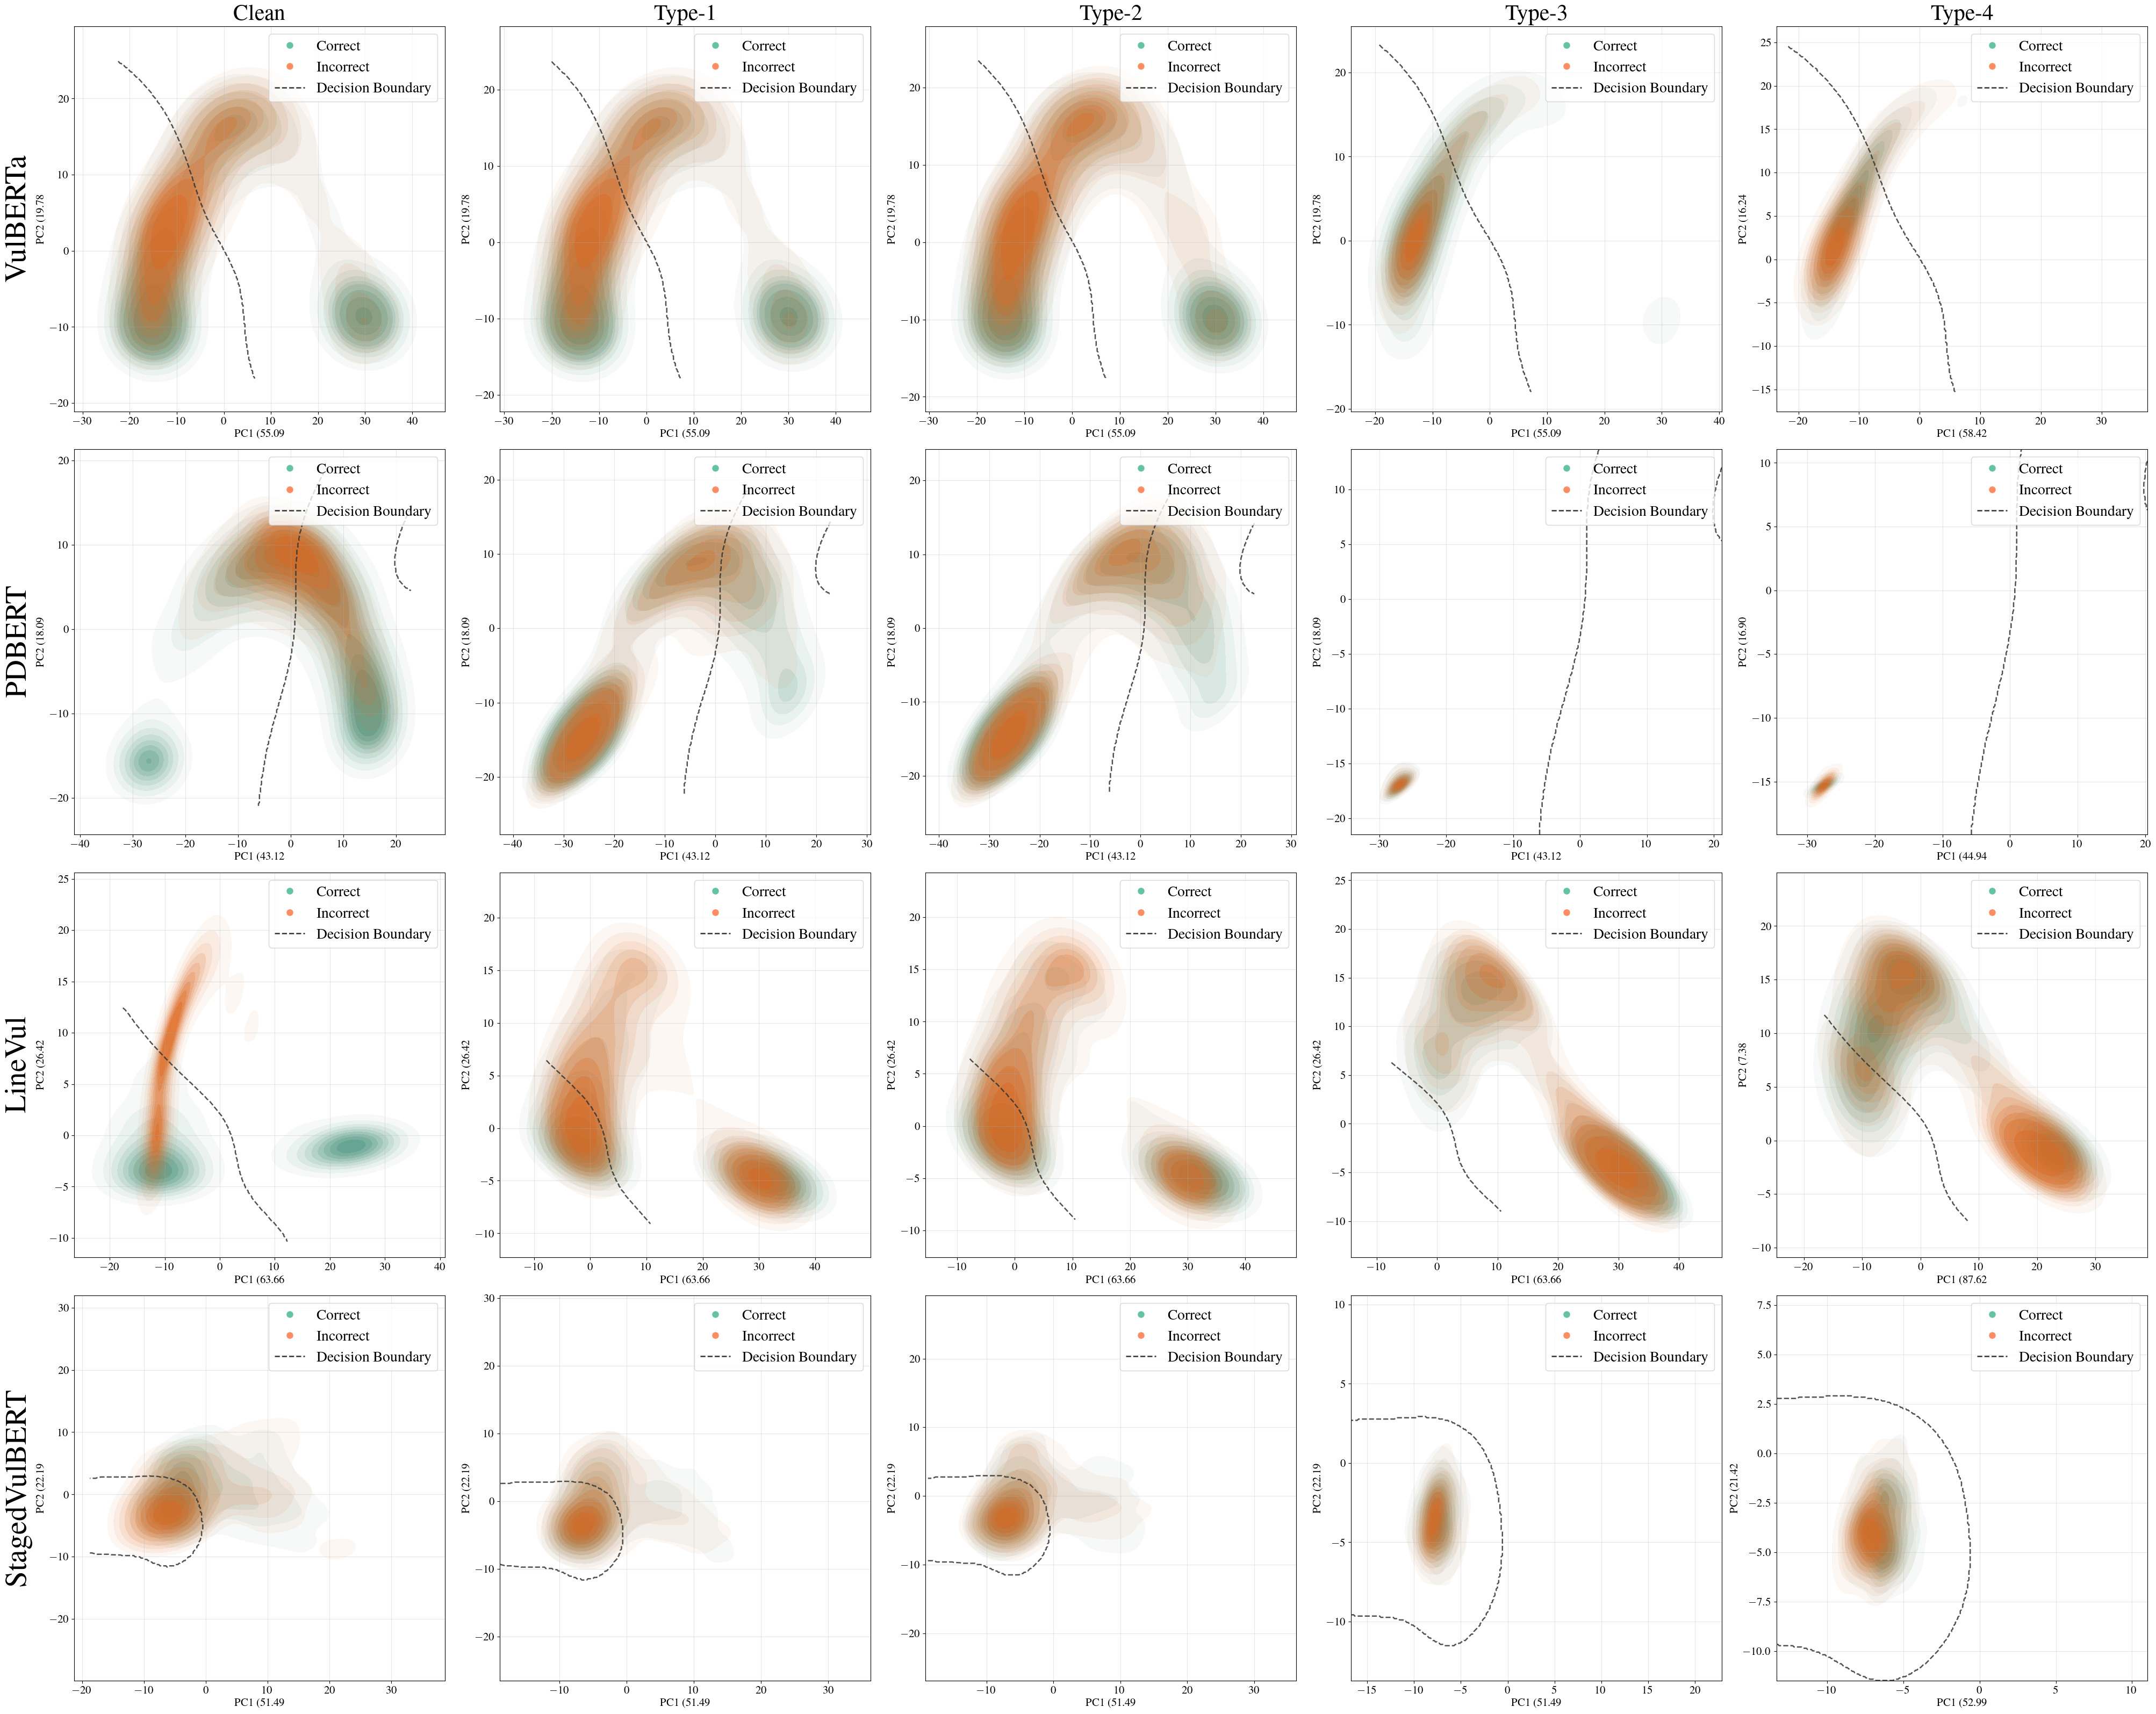

In [33]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def _balanced_sample(pca2, labels, preds, max_points, seed=42):
    n = len(pca2)
    if max_points is None or n <= max_points:
        return pca2, labels, preds
    rng      = np.random.default_rng(seed)
    vul_idx  = np.where(labels == 1)[0]
    safe_idx = np.where(labels == 0)[0]
    n_per    = max_points // 2
    s_vul    = rng.choice(vul_idx,  size=min(len(vul_idx),  n_per), replace=False)
    s_safe   = rng.choice(safe_idx, size=min(len(safe_idx), n_per), replace=False)
    idx      = np.concatenate([s_vul, s_safe])
    return pca2[idx], labels[idx], preds[idx]

'''
# ── balanced sampling helper ─────────────────────────────────────────────────
def _balanced_sample(pca2, labels, preds, max_points):
    n = len(pca2)
    if max_points is None or n <= max_points:
        return pca2, labels, preds
    np.random.seed(42)
    vul_idx  = np.where(labels == 1)[0]
    safe_idx = np.where(labels == 0)[0]
    n_per = min(len(vul_idx), len(safe_idx), max_points // 2)
    if n_per == 0:
        idx = np.random.choice(n, size=max_points, replace=False)
    else:
        sv = np.random.choice(vul_idx,  size=n_per, replace=False)
        ss = np.random.choice(safe_idx, size=n_per, replace=False)
        idx = np.concatenate([sv, ss])
        rem = np.setdiff1d(np.arange(n), idx)
        n_ex = max_points - len(idx)
        if n_ex > 0 and len(rem) > 0:
            idx = np.concatenate([idx, np.random.choice(rem, size=min(n_ex, len(rem)), replace=False)])
        np.random.shuffle(idx)
    return pca2[idx], labels[idx], preds[idx]
'''

# ── faded KDE helper ─────────────────────────────────────────────────────────
def _plot_faded_kde(ax, df, group_col, groups_colors, kde_fade_layers, min_kde_points):
    """Faded layered KDE when >= min_kde_points, scatter fallback otherwise."""
    for name, color in groups_colors:
        subset = df[df[group_col] == name]
        if len(subset) == 0:
            continue
        if len(subset) >= min_kde_points:
            try:
                for thresh, alpha in kde_fade_layers:
                    sns.kdeplot(data=subset, x='PC1', y='PC2',
                                fill=True, levels=2, alpha=alpha,
                                color=color, ax=ax, thresh=thresh)
            except Exception:
                ax.scatter(subset['PC1'], subset['PC2'],
                           c=color, s=12, alpha=0.4, linewidths=0)
        elif len(subset) >= 5:
            ax.scatter(subset['PC1'], subset['PC2'],
                       c=color, s=25, alpha=0.7, edgecolors='k', linewidths=0.2, zorder=4)
        else:
            ax.scatter(subset['PC1'], subset['PC2'],
                       c=color, s=40, alpha=0.9, edgecolors='k', linewidths=0.4, zorder=5)


def plot_pca_all_models_all_perturbations(
        model_names,
        perturbations,
        split='train',
        mode='both',
        max_points=2000,
        vuln_min_warn=50,
        figsize=(28, 8),
        save_path=None,
        boundary_resolution=300,
        boundary_alpha=0.85,
        boundary_linewidth=1.8,
        boundary_color='#333333',
        svm_C=1.0,
        svm_gamma='scale',
        min_kde_points=100,
        kde_fade_layers=(
            (0.1, 0.05), (0.20, 0.07), (0.30, 0.1),  (0.40, 0.13),
            (0.5, 0.15), (0.6,  0.2),  (0.7,  0.25), (0.8,  0.3), (0.9, 0.4)
        ),
):
    mpl.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
        "axes.unicode_minus": False,
    })

    assert mode in ('both', 'label', 'correctness'), \
        "mode must be 'both', 'label', or 'correctness'"

    show_lbl = mode in ('both', 'label')
    show_cor = mode in ('both', 'correctness')
    rows_per_model = 2 if mode == 'both' else 1

    ncols = 1 + len(perturbations)
    nrows = rows_per_model * len(model_names)
    fig_h = figsize[1] * len(model_names)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], fig_h), squeeze=False)

    FS_TITLE = 30
    FS_AXIS  = 15
    FS_TICK  = 15
    FS_LEG   = 20
    FS_MODEL = 40

    col_labels = ['Clean'] + [
        f"Type-{p[4:]}" if p.lower().startswith('type') else p.capitalize()
        for p in perturbations
    ]
    for col, col_label in enumerate(col_labels):
        axes[0][col].set_title(col_label, fontsize=FS_TITLE, fontweight='bold', pad=8)

    LABEL_GROUPS   = [('Safe', '#377eb8'), ('Vulnerable', '#e41a1c')]
    CORRECT_GROUPS = [(True,  '#66c2a5'),  (False, '#fc8d62')]

    LEG_LABEL = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#377eb8', markersize=10, label='Safe'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#e41a1c', markersize=10, label='Vulnerable'),
        Line2D([0],[0], color=boundary_color, linewidth=boundary_linewidth, linestyle='--', label='Decision Boundary'),
    ]
    LEG_CORRECT = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#66c2a5', markersize=10, label='Correct'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#fc8d62', markersize=10, label='Incorrect'),
        Line2D([0],[0], color=boundary_color, linewidth=boundary_linewidth, linestyle='--', label='Decision Boundary'),
    ]

    for m_idx, model_name in enumerate(model_names):
        base_row  = rows_per_model * m_idx
        row_lbl   = base_row
        row_cor   = base_row + 1 if mode == 'both' else base_row
        base_path = model_paths[model_name]

        # ── A. Load raw TRAIN features, fit PCA + surrogate SVM ───────────
        surrogate    = None
        scaler_2d    = None
        pca          = None
        train_labels = None

        clean_train_pkl = f"{base_path}/clean_train_features.pkl"
        try:
            clean_train_raw = np.asarray(pickle.load(open(clean_train_pkl, 'rb')))
            n_components    = min(50, clean_train_raw.shape[1])
            pca             = PCA(n_components=n_components, random_state=42)
            pca.fit(clean_train_raw)
            train_pca2      = pca.transform(clean_train_raw)[:, :2]

            for pert in perturbations:
                try:
                    td = pickle.load(open(f"{base_path}/{pert}_train_pca_comparison.pkl", 'rb'))
                    train_labels = np.asarray(td['clean_labels'])
                    break
                except FileNotFoundError:
                    continue

            if train_labels is None:
                print(f"[{model_name}] Could not load train labels — skipping boundary.")
            else:
                # Fit on full training set, same as adversarial function
                scaler_2d  = StandardScaler()
                X2d_scaled = scaler_2d.fit_transform(train_pca2)
                surrogate  = SVC(
                    kernel='rbf', C=svm_C, gamma=svm_gamma,
                    class_weight='balanced', probability=True, random_state=42,
                )
                surrogate.fit(X2d_scaled, train_labels)
                print(f"[{model_name}] Surrogate SVM fitted on {len(train_labels)} train samples.")

        except FileNotFoundError:
            print(f"[{model_name}] clean_train_features.pkl not found — boundary will be skipped.")

        # ── B. Helper: draw boundary ───────────────────────────────────────
        def _draw_boundary(ax, pca2_data):
            if surrogate is None or scaler_2d is None:
                return
            x_min, x_max = pca2_data[:, 0].min(), pca2_data[:, 0].max()
            y_min, y_max = pca2_data[:, 1].min(), pca2_data[:, 1].max()
            x_pad = (x_max - x_min) * 0.15
            y_pad = (y_max - y_min) * 0.15
            gx  = np.linspace(x_min - x_pad, x_max + x_pad, boundary_resolution)
            gy  = np.linspace(y_min - y_pad, y_max + y_pad, boundary_resolution)
            _xx, _yy    = np.meshgrid(gx, gy)
            mesh_scaled = scaler_2d.transform(np.c_[_xx.ravel(), _yy.ravel()])
            _Z = surrogate.predict_proba(mesh_scaled)[:, 1].reshape(_xx.shape)
            ax.contour(
                _xx, _yy, _Z, levels=[0.5],
                colors=[boundary_color], linestyles=['--'],
                linewidths=[boundary_linewidth], alpha=boundary_alpha, zorder=4,
            )

        # ── C. Load reference clean pkl for this split ────────────────────
        ref_data = None
        for pert in perturbations:
            try:
                ref_data = pickle.load(open(f"{base_path}/{pert}_{split}_pca_comparison.pkl", 'rb'))
                break
            except FileNotFoundError:
                continue

        if ref_data is None:
            print(f"[{model_name}] No pkl found — skipping.")
            for r in range(rows_per_model):
                for col in range(ncols):
                    axes[base_row + r][col].set_visible(False)
            continue

        # ── D. Project clean split features through TRAIN PCA ─────────────
        if pca is not None:
            try:
                clean_split_raw = np.asarray(
                    pickle.load(open(f"{base_path}/clean_{split}_features.pkl", 'rb'))
                )
                c_pca_all = pca.transform(clean_split_raw)[:, :2]
            except FileNotFoundError:
                print(f"[{model_name}] clean_{split}_features.pkl not found, using pca_comparison coords.")
                c_pca_all = np.asarray(ref_data['clean_features_pca'])[:, :2]
        else:
            c_pca_all = np.asarray(ref_data['clean_features_pca'])[:, :2]

        c_labels_all = np.asarray(ref_data['clean_labels'])
        c_preds_all  = np.asarray(ref_data['clean_predictions'])
        evr_c = ref_data.get('explained_variance_ratio', [0, 0])
        ev1_c = f"{evr_c[0]:.2%}"
        ev2_c = f"{evr_c[1]:.2%}"

        c_pca, c_labels, c_preds = _balanced_sample(c_pca_all, c_labels_all, c_preds_all, max_points)
        df_clean = pd.DataFrame({
            'PC1':     c_pca[:, 0], 'PC2': c_pca[:, 1],
            'Label':   ['Vulnerable' if l == 1 else 'Safe' for l in c_labels],
            'Correct': [l == p for l, p in zip(c_labels, c_preds)],
        })

        # ── E. Column 0: clean ────────────────────────────────────────────
        if show_lbl:
            _plot_faded_kde(axes[row_lbl][0], df_clean, 'Label', LABEL_GROUPS, kde_fade_layers, min_kde_points)
            _draw_boundary(axes[row_lbl][0], c_pca_all)
            axes[row_lbl][0].set_xlabel(f'PC1 ({ev1_c})', fontsize=FS_AXIS)
            axes[row_lbl][0].set_ylabel(f'PC2 ({ev2_c})', fontsize=FS_AXIS)
            axes[row_lbl][0].legend(handles=LEG_LABEL, loc='best', frameon=True, fontsize=FS_LEG)
            axes[row_lbl][0].tick_params(labelsize=FS_TICK)
            axes[row_lbl][0].grid(alpha=0.3)

        if show_cor:
            _plot_faded_kde(axes[row_cor][0], df_clean, 'Correct', CORRECT_GROUPS, kde_fade_layers, min_kde_points)
            _draw_boundary(axes[row_cor][0], c_pca_all)
            axes[row_cor][0].set_xlabel(f'PC1 ({ev1_c})', fontsize=FS_AXIS)
            axes[row_cor][0].set_ylabel(f'PC2 ({ev2_c})', fontsize=FS_AXIS)
            axes[row_cor][0].legend(handles=LEG_CORRECT, loc='best', frameon=True, fontsize=FS_LEG)
            axes[row_cor][0].tick_params(labelsize=FS_TICK)
            axes[row_cor][0].grid(alpha=0.3)

        # Model name annotation on column 0
        if mode == 'both':
            axes[row_lbl][0].set_ylabel(f'PC2 ({ev2_c})', fontsize=FS_AXIS)
            axes[row_cor][0].set_ylabel(f'PC2 ({ev2_c})', fontsize=FS_AXIS)
            axes[row_lbl][0].annotate(
                model_name,
                xy=(-0.10, 0.0), xycoords='axes fraction',
                fontsize=FS_MODEL, fontweight='bold', rotation=90,
                ha='center', va='center', annotation_clip=False,
            )
        else:
            axes[base_row][0].set_ylabel(f'PC2 ({ev2_c})', fontsize=FS_AXIS)
            axes[base_row][0].annotate(
                model_name,
                xy=(-0.15, 0.5), xycoords='axes fraction',
                fontsize=FS_MODEL, fontweight='bold', rotation=90,
                ha='center', va='center', annotation_clip=False,
            )

        # ── F. Columns 1…n: perturbations ─────────────────────────────────
        for col, pert in enumerate(perturbations, start=1):
            try:
                data = pickle.load(open(f"{base_path}/{pert}_{split}_pca_comparison.pkl", 'rb'))
            except FileNotFoundError:
                print(f"  [{model_name}] {pert} not found — skipping.")
                for r in range(rows_per_model):
                    axes[base_row + r][col].set_visible(False)
                continue

            p_labels_all = np.asarray(data['perturbed_labels'])
            p_preds_all  = np.asarray(data['perturbed_predictions'])
            evr_p = data.get('explained_variance_ratio', [0, 0])
            ev1_p = f"{evr_p[0]:.2%}"
            ev2_p = f"{evr_p[1]:.2%}"

            if pca is not None:
                try:
                    pert_raw  = np.asarray(pickle.load(open(f"{base_path}/{pert}_{split}_features.pkl", 'rb')))
                    p_pca_all = pca.transform(pert_raw)[:, :2]
                except FileNotFoundError:
                    print(f"  [{model_name}] {pert}_{split}_features.pkl not found, using pca_comparison coords.")
                    p_pca_all = np.asarray(data['perturbed_features_pca'])[:, :2]
            else:
                p_pca_all = np.asarray(data['perturbed_features_pca'])[:, :2]

            p_pca, p_labels, p_preds = _balanced_sample(p_pca_all, p_labels_all, p_preds_all, max_points)
            df_pert = pd.DataFrame({
                'PC1':     p_pca[:, 0], 'PC2': p_pca[:, 1],
                'Label':   ['Vulnerable' if l == 1 else 'Safe' for l in p_labels],
                'Correct': [l == p for l, p in zip(p_labels, p_preds)],
            })

            if show_lbl:
                _plot_faded_kde(axes[row_lbl][col], df_pert, 'Label', LABEL_GROUPS, kde_fade_layers, min_kde_points)
                _draw_boundary(axes[row_lbl][col], p_pca_all)
                axes[row_lbl][col].set_xlabel(f'PC1 ({ev1_p})', fontsize=FS_AXIS)
                axes[row_lbl][col].set_ylabel(f'PC2 ({ev2_p})', fontsize=FS_AXIS)
                axes[row_lbl][col].legend(handles=LEG_LABEL, loc='best', frameon=True, fontsize=FS_LEG)
                axes[row_lbl][col].tick_params(labelsize=FS_TICK)
                axes[row_lbl][col].grid(alpha=0.3)

            if show_cor:
                _plot_faded_kde(axes[row_cor][col], df_pert, 'Correct', CORRECT_GROUPS, kde_fade_layers, min_kde_points)
                _draw_boundary(axes[row_cor][col], p_pca_all)
                axes[row_cor][col].set_xlabel(f'PC1 ({ev1_p})', fontsize=FS_AXIS)
                axes[row_cor][col].set_ylabel(f'PC2 ({ev2_p})', fontsize=FS_AXIS)
                axes[row_cor][col].legend(handles=LEG_CORRECT, loc='best', frameon=True, fontsize=FS_LEG)
                axes[row_cor][col].tick_params(labelsize=FS_TICK)
                axes[row_cor][col].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────
perturbations = ['type1', 'type2', 'type3', 'type4']
split = 'test' # train or test
mode = 'correctness' # 'both' for separate label and correctness plots, 'label' for only label, 'correctness' for only correctness
plot_pca_all_models_all_perturbations(
    model_names,
    perturbations,
    split=split,
    mode=mode,
    max_points=2000,
    figsize=(40, 8),
    svm_C=1.0,
    svm_gamma='scale',
    min_kde_points=100,
    kde_fade_layers=(
        (0.1, 0.05), (0.20, 0.07), (0.30, 0.1),  (0.40, 0.13),
        (0.5, 0.15), (0.6,  0.2),  (0.7,  0.25), (0.8,  0.3), (0.9, 0.4)
    ),
    save_path=f'pca_{mode}_all_models_all_pert_{split}.pdf',
)






# Adversarial Evaluation Results

Results from attribution-guided adversarial attacks on vulnerable samples.

In [17]:
# Load adversarial results for all models
import json
import pickle

model_paths_adv = {
    'VulBERTa': './VulBERTa',
    'PDBERT': './PDBERT/downstream',
    'LineVul': './LineVul/linevul',
    'StagedVulBERT': './StagedVulBERT/Entry'
}

# Load JSON results to get flip statistics
adversarial_results_train = {}
adversarial_results_test = {}

for model_name, path in model_paths_adv.items():
    # Load train results
    train_file = f"{path}/adversarial_train_new.json"
    try:
        with open(train_file, 'r') as f:
            data = json.load(f)
            adversarial_results_train[model_name] = data
            print(f"✓ Loaded {len(data)} train samples for {model_name}")
    except FileNotFoundError:
        print(f"⚠️  No train adversarial results found for {model_name}")
        adversarial_results_train[model_name] = []
    
    # Load test results
    test_file = f"{path}/adversarial_test_new.json"
    try:
        with open(test_file, 'r') as f:
            data = json.load(f)
            adversarial_results_test[model_name] = data
            print(f"✓ Loaded {len(data)} test samples for {model_name}")
    except FileNotFoundError:
        print(f"⚠️  No test adversarial results found for {model_name}")
        adversarial_results_test[model_name] = []

print("\nAdversarial results loaded successfully!")

✓ Loaded 1000 train samples for VulBERTa
✓ Loaded 1000 test samples for VulBERTa
✓ Loaded 212 train samples for PDBERT
✓ Loaded 154 test samples for PDBERT
✓ Loaded 418 train samples for LineVul
✓ Loaded 423 test samples for LineVul
✓ Loaded 1000 train samples for StagedVulBERT
✓ Loaded 1000 test samples for StagedVulBERT

Adversarial results loaded successfully!


In [28]:
# Calculate flip statistics for each model (train and test)
flip_stats_train = {}
flip_stats_test = {}

# Process train results
for model_name, results in adversarial_results_train.items():
    if len(results) == 0:
        continue
    
    total_samples = len(results)
    successful_flips = sum(1 for r in results if r.get('flipped', False) and r.get('modified_code') is not None and r.get('new_prediction') is not None)
    failed_flips = sum(1 for r in results if not r.get('flipped', False) and r.get('modified_code') is not None and r.get('new_prediction') is not None)
    errors = sum(1 for r in results if r.get('new_prediction') is None)
    not_vulnerable = sum(1 for r in results if r.get('modified_code') is None)
    
    total_tested = successful_flips + failed_flips
    flip_rate = (successful_flips / total_tested * 100) if total_tested > 0 else 0
    
    flip_stats_train[model_name] = {
        'total_samples': total_samples,
        'successful_flips': successful_flips,
        'failed_flips': failed_flips,
        'errors': errors,
        'total_tested': total_tested,
        'flip_rate': flip_rate,
        'not_vulnerable': not_vulnerable
    }
    
    print(f"\n{model_name} (TRAIN):")
    print(f"  Total samples: {total_samples}")
    print(f"  Total tested: {total_tested}")
    print(f"  Successful flips: {successful_flips} ({flip_rate:.1f}%)")
    print(f"  Failed flips: {failed_flips} ({100 - flip_rate:.1f}%)")
    print(f"  Errors: {errors} ({(errors / total_samples * 100) if total_samples > 0 else 0:.1f}%)")
    print(f"  Not vulnerable: {not_vulnerable} ({(not_vulnerable / total_samples * 100) if total_samples > 0 else 0:.1f}%)")
# Process test results
for model_name, results in adversarial_results_test.items():
    if len(results) == 0:
        continue
    
    total_samples = len(results)
    successful_flips = sum(1 for r in results if r.get('flipped', False) and r.get('modified_code') is not None and r.get('new_prediction') is not None)
    failed_flips = sum(1 for r in results if not r.get('flipped', False) and r.get('modified_code') is not None and r.get('new_prediction') is not None)
    errors = sum(1 for r in results if r.get('new_prediction') is None)
    not_vulnerable = sum(1 for r in results if r.get('original_prediction') == 0)
    
    total_tested = successful_flips + failed_flips
    flip_rate = (successful_flips / total_tested * 100) if total_tested > 0 else 0
    
    flip_stats_test[model_name] = {
        'total_samples': total_samples,
        'successful_flips': successful_flips,
        'failed_flips': failed_flips,
        'errors': errors,
        'total_tested': total_tested,
        'flip_rate': flip_rate,
        'not_vulnerable': not_vulnerable
    }
    
    print(f"\n{model_name} (TEST):")
    print(f"  Total samples: {total_samples}")
    print(f"  Total tested: {total_tested}")
    print(f"  Successful flips: {successful_flips} ({flip_rate:.1f}%)")
    print(f"  Failed flips: {failed_flips} ({100 - flip_rate:.1f}%)")
    print(f"  Errors: {errors} ({(errors / total_samples * 100) if total_samples > 0 else 0:.1f}%)")
    print(f"  Not vulnerable: {not_vulnerable} ({(not_vulnerable / total_samples * 100) if total_samples > 0 else 0:.1f}%)")


VulBERTa (TRAIN):
  Total samples: 1000
  Total tested: 569
  Successful flips: 328 (57.6%)
  Failed flips: 241 (42.4%)
  Errors: 178 (17.8%)
  Not vulnerable: 253 (25.3%)

PDBERT (TRAIN):
  Total samples: 212
  Total tested: 212
  Successful flips: 11 (5.2%)
  Failed flips: 201 (94.8%)
  Errors: 0 (0.0%)
  Not vulnerable: 0 (0.0%)

LineVul (TRAIN):
  Total samples: 418
  Total tested: 227
  Successful flips: 64 (28.2%)
  Failed flips: 163 (71.8%)
  Errors: 104 (24.9%)
  Not vulnerable: 87 (20.8%)

StagedVulBERT (TRAIN):
  Total samples: 1000
  Total tested: 924
  Successful flips: 606 (65.6%)
  Failed flips: 318 (34.4%)
  Errors: 71 (7.1%)
  Not vulnerable: 5 (0.5%)

VulBERTa (TEST):
  Total samples: 1000
  Total tested: 376
  Successful flips: 215 (57.2%)
  Failed flips: 161 (42.8%)
  Errors: 158 (15.8%)
  Not vulnerable: 466 (46.6%)

PDBERT (TEST):
  Total samples: 154
  Total tested: 154
  Successful flips: 9 (5.8%)
  Failed flips: 145 (94.2%)
  Errors: 0 (0.0%)
  Not vulnerable: 

## PCA Analysis of Adversarial Perturbations

Visualize how vulnerable samples move in the embedding space after adversarial token injection.

Saved to: adversarial_one_densities_train.pdf


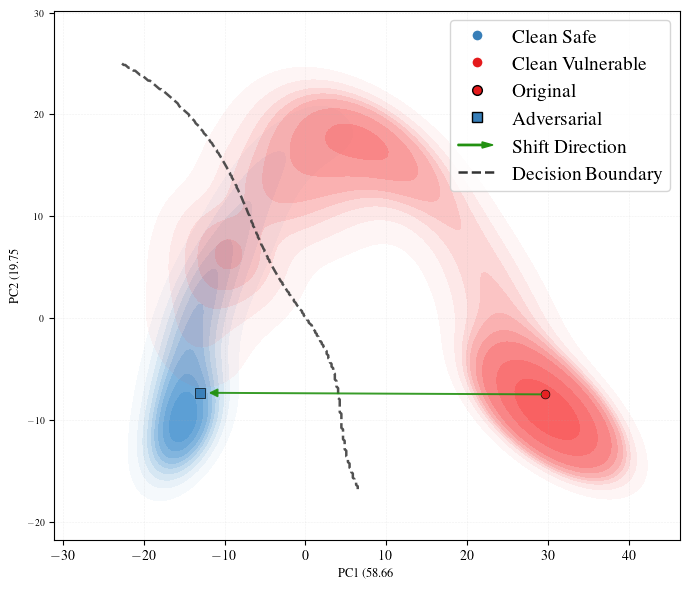

In [ ]:
import numpy as np
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrow
from matplotlib.legend_handler import HandlerPatch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def plot_adversarial_new_over_clean_densities(
        model_paths,
        adversarial_features_paths,
        models,
        split='train',
        perturbation='type3',
        padding=0.15,
        max_background=2000,
        max_samples=None,
        min_kde_points=100,
        random_seed=42,
        figsize=(21, 6),
        save_path=None,
        boundary_resolution=300,
        boundary_alpha=0.85,
        boundary_linewidth=1.8,
        svm_C=1.0,
        svm_gamma='scale',
):
    rng = np.random.default_rng(random_seed)

    COLOR_SAFE     = '#377eb8'
    COLOR_VUL      = '#e41a1c'
    COLOR_ORIG     = '#e41a1c'
    COLOR_ADV      = '#377eb8'
    ARROW_COLOR    = "#229111"
    BOUNDARY_COLOR = '#333333'

    class _ArrowHandler(HandlerPatch):
        def create_artists(self, legend, orig_handle,
                           xdescent, ydescent, width, height, fontsize, trans):
            p = FancyArrow(xdescent, ydescent + height / 2, width * 0.9, 0,
                           width=height * 0.10, head_width=height * 0.45,
                           head_length=width * 0.28, length_includes_head=True,
                           facecolor=orig_handle.get_facecolor(),
                           edgecolor=orig_handle.get_facecolor())
            p.set_transform(trans)
            return [p]

    ncols = len(models)
    fig, axes = plt.subplots(1, ncols, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()

    for ax, model_name in zip(axes_flat, models):
        ax.clear()

        # ── 1. Load clean raw features and fit PCA ─────────────────────────
        clean_feats_pkl = f"{model_paths[model_name]}/clean_{split}_features.pkl"
        try:
            clean_raw = np.asarray(pickle.load(open(clean_feats_pkl, 'rb')))
        except Exception as e:
            ax.text(0.5, 0.5, f"Cannot load clean features\n{e}",
                    ha='center', va='center', fontsize=9)
            ax.set_title(model_name); ax.set_xticks([]); ax.set_yticks([])
            continue

        n_components = min(50, clean_raw.shape[1])
        pca = PCA(n_components=n_components, random_state=random_seed)
        pca.fit(clean_raw)
        clean_pca2 = pca.transform(clean_raw)[:, :2]

        # ── 2. Load clean labels + explained variance ──────────────────────
        pca_cmp_pkl = f"{model_paths[model_name]}/{perturbation}_{split}_pca_comparison.pkl"
        try:
            pca_cmp = pickle.load(open(pca_cmp_pkl, 'rb'))
        except Exception as e:
            ax.text(0.5, 0.5, f"Cannot load pca_comparison\n{e}",
                    ha='center', va='center', fontsize=9)
            ax.set_title(model_name); ax.set_xticks([]); ax.set_yticks([])
            continue

        clean_labels = np.asarray(pca_cmp['clean_labels'])
        evr = pca_cmp.get('explained_variance_ratio', pca.explained_variance_ratio_[:2].tolist())

        # ── 3. Load adversarial features and project through clean PCA ─────
        adv_pkl = adversarial_features_paths[model_name]
        try:
            adv_data = pickle.load(open(adv_pkl, 'rb'))
        except Exception as e:
            ax.text(0.5, 0.5, f"Cannot load adversarial features\n{e}",
                    ha='center', va='center', fontsize=9)
            ax.set_title(model_name); ax.set_xticks([]); ax.set_yticks([])
            continue

        orig_feats   = np.asarray(adv_data['original_features'])
        adv_feats    = np.asarray(adv_data['adversarial_features'])
        flip_success = np.asarray(adv_data['flip_success'], dtype=bool)

        orig_pca2 = pca.transform(orig_feats)[:, :2]
        adv_pca2  = pca.transform(adv_feats)[:, :2]

        # ── 4. Balanced subsample of clean background points ───────────────
        n_clean = len(clean_pca2)
        if max_background is not None and n_clean > max_background:
            vul_idx  = np.where(clean_labels == 1)[0]
            safe_idx = np.where(clean_labels == 0)[0]
            n_per    = max_background // 2
            s_vul    = rng.choice(vul_idx,  size=min(len(vul_idx),  n_per), replace=False)
            s_safe   = rng.choice(safe_idx, size=min(len(safe_idx), n_per), replace=False)
            bg_idx   = np.concatenate([s_vul, s_safe])
        else:
            bg_idx = np.arange(n_clean)

        bg_pca2   = clean_pca2[bg_idx]
        bg_labels = clean_labels[bg_idx]

        df_bg = pd.DataFrame({
            'PC1':   bg_pca2[:, 0],
            'PC2':   bg_pca2[:, 1],
            'Label': ['Vulnerable' if l == 1 else 'Safe' for l in bg_labels],
        })

        # ── 5. Fit surrogate RBF SVM in 2D PCA space ──────────────────────
        scaler_2d  = StandardScaler()
        X2d_scaled = scaler_2d.fit_transform(clean_pca2)
        surrogate  = SVC(
            kernel='rbf',
            C=svm_C,
            gamma=svm_gamma,
            class_weight='balanced',
            probability=True,
            random_state=random_seed,
        )
        surrogate.fit(X2d_scaled, clean_labels)

        # ── 6. Build mesh for decision boundary contour ────────────────────
        x_min, x_max = clean_pca2[:, 0].min(), clean_pca2[:, 0].max()
        y_min, y_max = clean_pca2[:, 1].min(), clean_pca2[:, 1].max()
        x_pad = (x_max - x_min) * padding
        y_pad = (y_max - y_min) * padding
        xx, yy = np.meshgrid(
            np.linspace(x_min - x_pad, x_max + x_pad, boundary_resolution),
            np.linspace(y_min - y_pad, y_max + y_pad, boundary_resolution),
        )
        mesh_pts    = np.c_[xx.ravel(), yy.ravel()]
        mesh_scaled = scaler_2d.transform(mesh_pts)
        Z = surrogate.predict_proba(mesh_scaled)[:, 1].reshape(xx.shape)

        # ── 7. KDE background: Safe first (underneath), Vulnerable on top ──
        for lbl, color in [('Safe', COLOR_SAFE), ('Vulnerable', COLOR_VUL)]:
            subset = df_bg[df_bg['Label'] == lbl]
            if len(subset) < min_kde_points:
                # Too few points — scatter only, no KDE
                ax.scatter(subset['PC1'], subset['PC2'],
                           c=color, s=25, alpha=0.7, edgecolors='k', linewidths=0.2)
                continue
            try:
                # Draw layers from outermost (transparent) to innermost (opaque)
                # Each layer starts at a higher thresh, so only denser regions show
                for thresh, alpha in [(0.1, 0.05), (0.20, 0.07), (0.30, 0.1), (0.40, 0.13), (0.5, 0.15), (0.6,0.2),(0.7,0.25),(0.8, 0.3), (0.9,0.4)]:
                    sns.kdeplot(data=subset, x='PC1', y='PC2',
                                fill=True, levels=2, alpha=alpha, color=color, ax=ax,
                                thresh=thresh)
            except Exception as e:
                print(f"[{model_name}] KDE {lbl} failed: {e}")
                ax.scatter(subset['PC1'], subset['PC2'],
                           c=color, s=12, alpha=0.4, linewidths=0)

        # ── 8. Decision boundary contour at p=0.5 ─────────────────────────
        ax.contour(
            xx, yy, Z,
            levels=[0.5],
            colors=[BOUNDARY_COLOR],
            linestyles=['--'],
            linewidths=[boundary_linewidth],
            alpha=boundary_alpha,
            zorder=4,
        )

        # ── 9. Overlay adversarial dots + arrows ───────────────────────────
        idx_flip = np.where(flip_success)[0]
        n_flip   = len(idx_flip)
        total    = len(flip_success)

        if n_flip == 0:
            ax.text(0.5, 0.5, f'No flipped samples\n({total} total)',
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            chosen = np.array([], dtype=int)
        else:
            # Score all flipped pairs against the surrogate boundary
            o_all  = orig_pca2[idx_flip]
            a_all  = adv_pca2[idx_flip]
            p_orig = surrogate.predict_proba(scaler_2d.transform(o_all))[:, 1]
            p_adv  = surrogate.predict_proba(scaler_2d.transform(a_all))[:, 1]

            # Filter to true boundary crossers: orig in vul region, adv in safe region
            is_crosser  = (p_orig > 0.5) & (p_adv < 0.5)
            crosser_idx = np.where(is_crosser)[0]

            if len(crosser_idx) == 0:
                print(f"[{model_name}] No boundary-crossing pairs found, falling back to random sampling")
                pool = np.arange(n_flip)
            else:
                pool = crosser_idx

            if max_samples is not None and max_samples < len(pool):
                chosen = rng.choice(pool, size=max_samples, replace=False)
            else:
                chosen = pool.copy()

            chosen = np.sort(chosen)

            o_show = orig_pca2[idx_flip[chosen]]
            a_show = adv_pca2[idx_flip[chosen]]

            ax.scatter(o_show[:, 0], o_show[:, 1], s=40, marker='o', color=COLOR_ORIG,
                       edgecolors='k', linewidths=0.5, alpha=0.9, zorder=5)
            ax.scatter(a_show[:, 0], a_show[:, 1], s=45, marker='s', color=COLOR_ADV,
                       edgecolors='k', linewidths=0.5, alpha=0.95, zorder=6)

            for li in range(len(chosen)):
                ax.annotate('', xy=(a_show[li, 0], a_show[li, 1]),
                            xytext=(o_show[li, 0], o_show[li, 1]),
                            arrowprops=dict(arrowstyle='-|>', mutation_scale=12,
                                            lw=1.4, color=ARROW_COLOR,
                                            alpha=0.9, shrinkA=3, shrinkB=6),
                            zorder=7)

        # ── 10. Decorations ────────────────────────────────────────────────
        ev1 = f"{evr[0]:.2%}" if not np.isnan(float(evr[0])) else "NA"
        ev2 = f"{evr[1]:.2%}" if not np.isnan(float(evr[1])) else "NA"
        ax.set_xlabel(f'PC1 ({ev1})', fontsize=9)
        ax.set_ylabel(f'PC2 ({ev2})', fontsize=9)
        ax.grid(alpha=0.2, linestyle='--', linewidth=0.4)

        arrow_proxy = FancyArrow(0, 0, 1, 0, facecolor=ARROW_COLOR,
                                 edgecolor=ARROW_COLOR, label='Shift Direction')
        legend_el = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_SAFE,
                   markersize=8, label='Clean Safe'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_VUL,
                   markersize=8, label='Clean Vulnerable'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_ORIG,
                   markeredgecolor='k', markersize=7, label='Original'),
            Line2D([0], [0], marker='s', color='w', markerfacecolor=COLOR_ADV,
                   markeredgecolor='k', markersize=7, label='Adversarial'),
            arrow_proxy,
            Line2D([0], [0], color=BOUNDARY_COLOR, linewidth=boundary_linewidth,
                   linestyle='--', label='Decision Boundary'),
        ]
        ax.legend(handles=legend_el, loc='best', frameon=True, fontsize=14,
                  handler_map={FancyArrow: _ArrowHandler()})

    for j in range(len(models), len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────
models_adv = ['VulBERTa']
adversarial_features_paths = {
    'VulBERTa':      './data/VulBERTa/adversarial_train_new_vulnerable_features.pkl',
    'LineVul':       './data/LineVul/linevul/adversarial_train_new_vulnerable_features.pkl',
    'StagedVulBERT': './data/StagedVulBERT/Entry/adversarial_train_new_vulnerable_features.pkl',
}
plot_adversarial_new_over_clean_densities(
    model_paths,
    adversarial_features_paths,
    models_adv,
    split='train',
    perturbation='type3',
    figsize=(7, 6),
    max_background=2000,
    max_samples=1,
    min_kde_points=100,
    svm_C=1.0,
    svm_gamma='scale',
    save_path='adversarial_one_densities_train.pdf',
)

Saved to: adversarial_all_densities_train_decision_bound.pdf


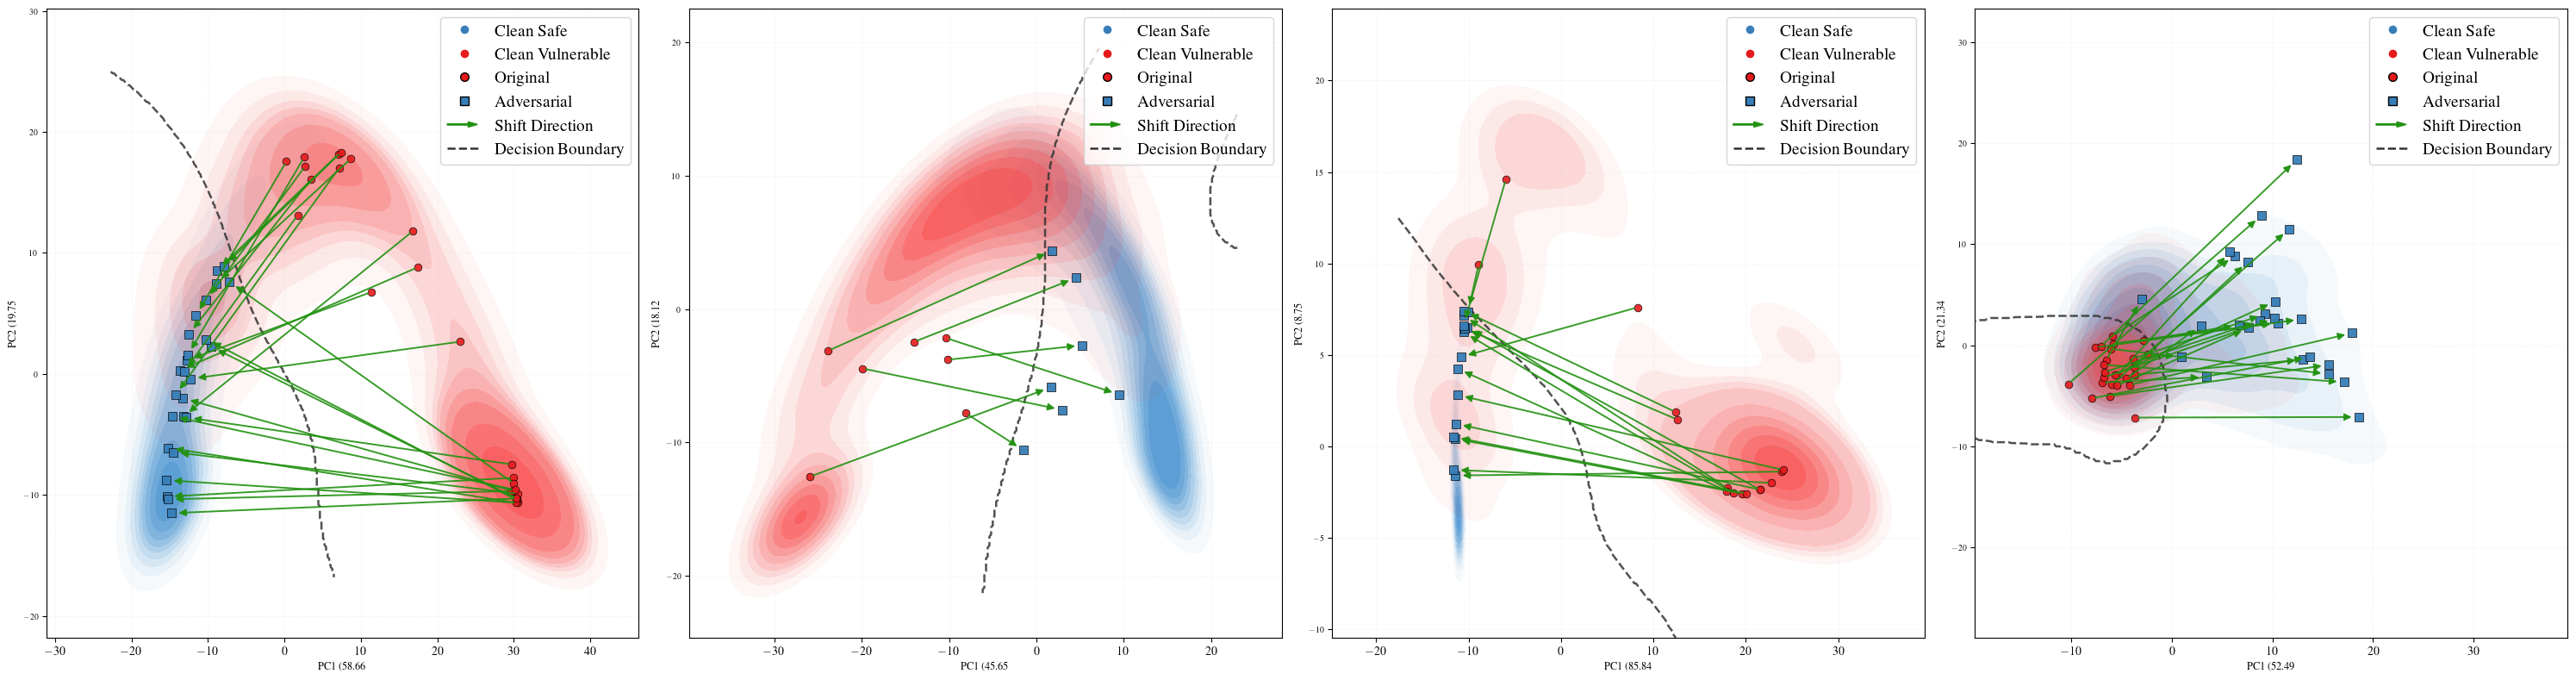

In [ ]:
import numpy as np
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrow
from matplotlib.legend_handler import HandlerPatch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "axes.unicode_minus": False,
})


def plot_adversarial_new_over_clean_densities(
        model_paths,
        adversarial_features_paths,
        models,
        split='train',
        perturbation='type3',
        padding=0.15,
        max_background=2000,
        max_samples=None,
        min_kde_points=100,
        random_seed=42,
        figsize=(21, 6),
        save_path=None,
        boundary_resolution=300,
        boundary_alpha=0.85,
        boundary_linewidth=1.8,
        svm_C=1.0,
        svm_gamma='scale',
        kde_fade_layers=[(0.10, 0.1), (0.20, 0.15), (0.30, 0.2), (0.50, 0.25)],
):
    rng = np.random.default_rng(random_seed)

    COLOR_SAFE     = '#377eb8'
    COLOR_VUL      = '#e41a1c'
    COLOR_ORIG     = '#e41a1c'
    COLOR_ADV      = '#377eb8'
    ARROW_COLOR    = "#229111"
    BOUNDARY_COLOR = '#333333'

    class _ArrowHandler(HandlerPatch):
        def create_artists(self, legend, orig_handle,
                           xdescent, ydescent, width, height, fontsize, trans):
            p = FancyArrow(xdescent, ydescent + height / 2, width * 0.9, 0,
                           width=height * 0.10, head_width=height * 0.45,
                           head_length=width * 0.28, length_includes_head=True,
                           facecolor=orig_handle.get_facecolor(),
                           edgecolor=orig_handle.get_facecolor())
            p.set_transform(trans)
            return [p]

    ncols = len(models)
    fig, axes = plt.subplots(1, ncols, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()

    for ax, model_name in zip(axes_flat, models):
        ax.clear()

        # ── 1. Load clean raw features and fit PCA ─────────────────────────
        clean_feats_pkl = f"{model_paths[model_name]}/clean_{split}_features.pkl"
        try:
            clean_raw = np.asarray(pickle.load(open(clean_feats_pkl, 'rb')))
        except Exception as e:
            ax.text(0.5, 0.5, f"Cannot load clean features\n{e}",
                    ha='center', va='center', fontsize=9)
            ax.set_title(model_name); ax.set_xticks([]); ax.set_yticks([])
            continue

        n_components = min(50, clean_raw.shape[1])
        pca = PCA(n_components=n_components, random_state=random_seed)
        pca.fit(clean_raw)
        clean_pca2 = pca.transform(clean_raw)[:, :2]

        # ── 2. Load clean labels + explained variance ──────────────────────
        pca_cmp_pkl = f"{model_paths[model_name]}/{perturbation}_{split}_pca_comparison.pkl"
        try:
            pca_cmp = pickle.load(open(pca_cmp_pkl, 'rb'))
        except Exception as e:
            ax.text(0.5, 0.5, f"Cannot load pca_comparison\n{e}",
                    ha='center', va='center', fontsize=9)
            ax.set_title(model_name); ax.set_xticks([]); ax.set_yticks([])
            continue

        clean_labels = np.asarray(pca_cmp['clean_labels'])
        evr = pca_cmp.get('explained_variance_ratio', pca.explained_variance_ratio_[:2].tolist())

        # ── 3. Load adversarial features and project through clean PCA ─────
        adv_pkl = adversarial_features_paths[model_name]
        try:
            adv_data = pickle.load(open(adv_pkl, 'rb'))
        except Exception as e:
            ax.text(0.5, 0.5, f"Cannot load adversarial features\n{e}",
                    ha='center', va='center', fontsize=9)
            ax.set_title(model_name); ax.set_xticks([]); ax.set_yticks([])
            continue

        orig_feats   = np.asarray(adv_data['original_features'])
        adv_feats    = np.asarray(adv_data['adversarial_features'])
        flip_success = np.asarray(adv_data['flip_success'], dtype=bool)

        orig_pca2 = pca.transform(orig_feats)[:, :2]
        adv_pca2  = pca.transform(adv_feats)[:, :2]

        # ── 4. Balanced subsample of clean background points ───────────────
        n_clean = len(clean_pca2)
        if max_background is not None and n_clean > max_background:
            vul_idx  = np.where(clean_labels == 1)[0]
            safe_idx = np.where(clean_labels == 0)[0]
            n_per    = max_background // 2
            s_vul    = rng.choice(vul_idx,  size=min(len(vul_idx),  n_per), replace=False)
            s_safe   = rng.choice(safe_idx, size=min(len(safe_idx), n_per), replace=False)
            bg_idx   = np.concatenate([s_vul, s_safe])
        else:
            bg_idx = np.arange(n_clean)

        bg_pca2   = clean_pca2[bg_idx]
        bg_labels = clean_labels[bg_idx]

        df_bg = pd.DataFrame({
            'PC1':   bg_pca2[:, 0],
            'PC2':   bg_pca2[:, 1],
            'Label': ['Vulnerable' if l == 1 else 'Safe' for l in bg_labels],
        })

        # ── 5. Fit surrogate RBF SVM in 2D PCA space ──────────────────────
        scaler_2d  = StandardScaler()
        X2d_scaled = scaler_2d.fit_transform(clean_pca2)
        surrogate  = SVC(
            kernel='rbf',
            C=svm_C,
            gamma=svm_gamma,
            class_weight='balanced',
            probability=True,
            random_state=random_seed,
        )
        surrogate.fit(X2d_scaled, clean_labels)

        # ── 6. Build mesh for decision boundary contour ────────────────────
        x_min, x_max = clean_pca2[:, 0].min(), clean_pca2[:, 0].max()
        y_min, y_max = clean_pca2[:, 1].min(), clean_pca2[:, 1].max()
        x_pad = (x_max - x_min) * padding
        y_pad = (y_max - y_min) * padding
        xx, yy = np.meshgrid(
            np.linspace(x_min - x_pad, x_max + x_pad, boundary_resolution),
            np.linspace(y_min - y_pad, y_max + y_pad, boundary_resolution),
        )
        mesh_pts    = np.c_[xx.ravel(), yy.ravel()]
        mesh_scaled = scaler_2d.transform(mesh_pts)
        Z = surrogate.predict_proba(mesh_scaled)[:, 1].reshape(xx.shape)

        # ── 7. KDE background: Safe first (underneath), Vulnerable on top ──
        # Faded layers: sparse outer regions are transparent, dense core is opaque.
        # thresh cuts regions below that fraction of peak density (sparse areas hidden).
        for lbl, color in [('Safe', COLOR_SAFE), ('Vulnerable', COLOR_VUL)]:
            subset = df_bg[df_bg['Label'] == lbl]
            if len(subset) < min_kde_points:
                ax.scatter(subset['PC1'], subset['PC2'],
                           c=color, s=25, alpha=0.7, edgecolors='k', linewidths=0.2)
                continue
            try:
                for thresh, alpha in kde_fade_layers:
                    sns.kdeplot(data=subset, x='PC1', y='PC2',
                                fill=True, levels=2, alpha=alpha, color=color,
                                ax=ax, thresh=thresh)
            except Exception as e:
                print(f"[{model_name}] KDE {lbl} failed: {e}")
                ax.scatter(subset['PC1'], subset['PC2'],
                           c=color, s=12, alpha=0.4, linewidths=0)

        # ── 8. Decision boundary contour at p=0.5 ─────────────────────────
        ax.contour(
            xx, yy, Z,
            levels=[0.5],
            colors=[BOUNDARY_COLOR],
            linestyles=['--'],
            linewidths=[boundary_linewidth],
            alpha=boundary_alpha,
            zorder=4,
        )

        # ── 9. Overlay adversarial dots + arrows ───────────────────────────
        idx_flip = np.where(flip_success)[0]
        n_flip   = len(idx_flip)
        total    = len(flip_success)

        if n_flip == 0:
            ax.text(0.5, 0.5, f'No flipped samples\n({total} total)',
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            chosen = np.array([], dtype=int)
        else:
            o_all  = orig_pca2[idx_flip]
            a_all  = adv_pca2[idx_flip]
            p_orig = surrogate.predict_proba(scaler_2d.transform(o_all))[:, 1]
            p_adv  = surrogate.predict_proba(scaler_2d.transform(a_all))[:, 1]

            is_crosser  = (p_orig > 0.5) & (p_adv < 0.5)
            crosser_idx = np.where(is_crosser)[0]

            if len(crosser_idx) == 0:
                print(f"[{model_name}] No boundary-crossing pairs found, falling back to random sampling")
                pool = np.arange(n_flip)
            else:
                pool = crosser_idx

            if max_samples is not None and max_samples < len(pool):
                chosen = rng.choice(pool, size=max_samples, replace=False)
            else:
                chosen = pool.copy()

            chosen = np.sort(chosen)

            o_show = orig_pca2[idx_flip[chosen]]
            a_show = adv_pca2[idx_flip[chosen]]

            ax.scatter(o_show[:, 0], o_show[:, 1], s=40, marker='o', color=COLOR_ORIG,
                       edgecolors='k', linewidths=0.5, alpha=0.9, zorder=5)
            ax.scatter(a_show[:, 0], a_show[:, 1], s=45, marker='s', color=COLOR_ADV,
                       edgecolors='k', linewidths=0.5, alpha=0.95, zorder=6)

            for li in range(len(chosen)):
                ax.annotate('', xy=(a_show[li, 0], a_show[li, 1]),
                            xytext=(o_show[li, 0], o_show[li, 1]),
                            arrowprops=dict(arrowstyle='-|>', mutation_scale=12,
                                            lw=1.4, color=ARROW_COLOR,
                                            alpha=0.9, shrinkA=3, shrinkB=6),
                            zorder=7)

        # ── 10. Decorations ────────────────────────────────────────────────
        ev1 = f"{evr[0]:.2%}" if not np.isnan(float(evr[0])) else "NA"
        ev2 = f"{evr[1]:.2%}" if not np.isnan(float(evr[1])) else "NA"
        ax.set_xlabel(f'PC1 ({ev1})', fontsize=9)
        ax.set_ylabel(f'PC2 ({ev2})', fontsize=9)
        ax.grid(alpha=0.2, linestyle='--', linewidth=0.4)

        arrow_proxy = FancyArrow(0, 0, 1, 0, facecolor=ARROW_COLOR,
                                 edgecolor=ARROW_COLOR, label='Shift Direction')
        legend_el = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_SAFE,
                   markersize=8, label='Clean Safe'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_VUL,
                   markersize=8, label='Clean Vulnerable'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_ORIG,
                   markeredgecolor='k', markersize=7, label='Original'),
            Line2D([0], [0], marker='s', color='w', markerfacecolor=COLOR_ADV,
                   markeredgecolor='k', markersize=7, label='Adversarial'),
            arrow_proxy,
            Line2D([0], [0], color=BOUNDARY_COLOR, linewidth=boundary_linewidth,
                   linestyle='--', label='Decision Boundary'),
        ]
        ax.legend(handles=legend_el, loc='best', frameon=True, fontsize=14,
                  handler_map={FancyArrow: _ArrowHandler()})

    for j in range(len(models), len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────
models_adv = ['VulBERTa', 'PDBERT', 'LineVul', 'StagedVulBERT']
adversarial_features_paths = {
    'VulBERTa':      './data/VulBERTa/adversarial_train_new_vulnerable_features.pkl',
    'PDBERT':        './data/PDBERT/downstream/adversarial_examples_train_new_vulnerable_pca.pkl',
    'LineVul':       './data/LineVul/linevul/adversarial_train_new_vulnerable_features.pkl',
    'StagedVulBERT': './data/StagedVulBERT/Entry/adversarial_train_new_vulnerable_features.pkl',
}
plot_adversarial_new_over_clean_densities(
    model_paths,
    adversarial_features_paths,
    models_adv,
    split='train',
    perturbation='type3',
    figsize=(30, 8),
    max_background=2000,
    max_samples=25,
    min_kde_points=100,
    svm_C=1.0,
    svm_gamma='scale',
    kde_fade_layers=[(0.1, 0.05), (0.20, 0.07), (0.30, 0.1), (0.40, 0.13), (0.5, 0.15), (0.6,0.2),(0.7,0.25),(0.8, 0.3), (0.9,0.4)],
    save_path='adversarial_all_densities_train_decision_bound.pdf',
)